# Vehicle Clustering Analysis

This notebook performs unsupervised clustering on a vehicle dataset to identify distinct market segments based on structural features such as engine size, electrification level, emissions, and efficiency metrics.

**Pipeline overview:**
1. Correlation analysis and feature selection
2. Standardisation (StandardScaler)
3. PCA dimensionality reduction (≥ 85% variance retained)
4. K selection via multi-metric evaluation → **K = 8 (recommended)**
5. Model comparison (KMeans / Hierarchical / GMM) at K = 8
6. Cluster visualisation, interpretation, and naming
7. Ground-truth validation
8. Supplementary robustness check at K = 4

> **Note on K selection:** The recommended and primary result throughout this notebook uses **K = 8**, selected by a combined rank across Silhouette, Davies–Bouldin, and Calinski–Harabasz scores. The final section repeats model comparison and visualisation at K = 4 solely as a supplementary robustness check to confirm that the elbow-suggested alternative does not outperform the multi-metric recommendation.

---
## Part 1 · Feature Selection

### 1.1 Correlation Analysis and Feature Review

Load the dataset, exclude non-numeric / identifier columns, compute the correlation matrix, and flag highly correlated pairs for manual review.

=== Step 2: Correlation Analysis for Clustering Features ===

Dataset shape: (7870, 30)
Total columns: 30

[Step 2A] Columns proactively excluded before correlation analysis:
 - Fuel_Type_Primary
 - Fuel_Type_Secondary
 - Make
 - Model
 - Transmission
 - Transmission_Type
 - Vehicle_Class
 - Vehicle_Type
 - vehicle_id

[Step 2B] Numeric columns kept for review: 21
['Num_Gears', 'Is_SUV', 'Is_Truck', 'Model_Year', 'Engine_Size_L', 'Cylinders', 'Motor_kW', 'Fuel_Cons_City_L100km', 'Fuel_Cons_Hwy_L100km', 'Fuel_Cons_Comb_L100km', 'Elec_Cons_Comb_kWh100km', 'Elec_Range_km', 'Total_Range_km', 'Recharge_Time_h', 'CO2_Emissions_g_km', 'Fuel_Efficiency_Index', 'CO2_per_L_engine', 'City_Hwy_Fuel_Ratio', 'Electric_Efficiency_Index', 'Range_per_ChargeHour', 'Elec_Range_Share']

Dropped all-missing columns: 0

Dropped constant columns: 0

Remaining numeric columns after basic cleaning: 21

[Step 2C] Missing summary:


,Feature,Missing_Count,Missing_Rate,Unique_Values,Dtype
0,Is_SUV,0,0.0,2,int64
1,Is_Truck,0,0.0,2,int64
2,Num_Gears,0,0.0,10,float64
3,Cylinders,0,0.0,10,float64
4,Model_Year,0,0.0,16,float64
5,Engine_Size_L,0,0.0,54,float64
6,Recharge_Time_h,0,0.0,104,float64
7,Fuel_Cons_Hwy_L100km,0,0.0,144,float64
8,Motor_kW,0,0.0,166,float64
9,Fuel_Cons_Comb_L100km,0,0.0,182,float64


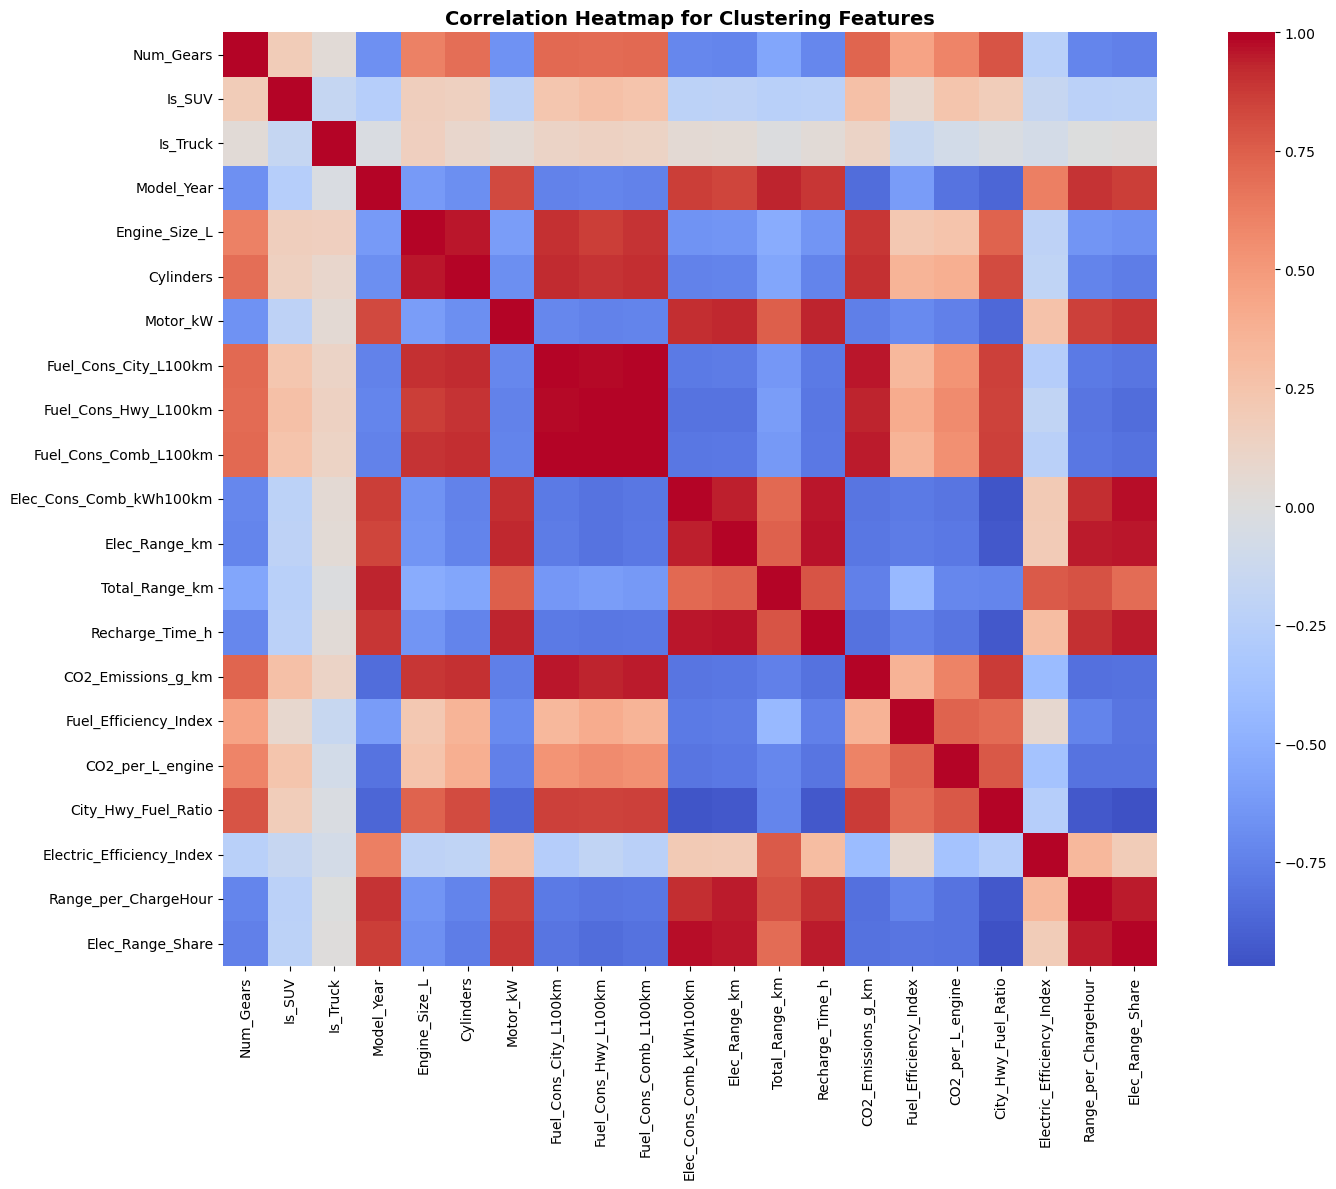


[Step 2D] Highly correlated pairs (|corr| > 0.9):


,Feature_1,Feature_2,Abs_Correlation
0,Fuel_Cons_City_L100km,Fuel_Cons_Comb_L100km,0.997218
1,Fuel_Cons_Hwy_L100km,Fuel_Cons_Comb_L100km,0.991417
2,Fuel_Cons_City_L100km,Fuel_Cons_Hwy_L100km,0.979049
3,Elec_Cons_Comb_kWh100km,Elec_Range_Share,0.971409
4,City_Hwy_Fuel_Ratio,Elec_Range_Share,0.969397
5,Elec_Range_km,Recharge_Time_h,0.964159
6,Elec_Range_km,Elec_Range_Share,0.960982
7,Elec_Cons_Comb_kWh100km,Recharge_Time_h,0.958904
8,Engine_Size_L,Cylinders,0.956728
9,Fuel_Cons_City_L100km,CO2_Emissions_g_km,0.955416



[Step 2E] Feature review table:


,Feature,Missing_Count,Missing_Rate,Unique_Values,Mean,Std,High_Corr_Count,High_Corr_Partners,Initial_Review,Manual_Decision,Reason
0,Recharge_Time_h,0,0.0,104,1.758831,3.927096,6,"City_Hwy_Fuel_Ratio, Elec_Cons_Comb_kWh100km, ...",Review: highly redundant,,
1,Elec_Cons_Comb_kWh100km,0,0.0,219,3.717344,8.526168,6,"City_Hwy_Fuel_Ratio, Elec_Range_Share, Elec_Ra...",Review: highly redundant,,
2,Elec_Range_km,0,0.0,291,70.209784,166.353459,6,"City_Hwy_Fuel_Ratio, Elec_Cons_Comb_kWh100km, ...",Review: highly redundant,,
3,Elec_Range_Share,0,0.0,187,0.155654,0.358248,5,"City_Hwy_Fuel_Ratio, Elec_Cons_Comb_kWh100km, ...",Review: highly redundant,,
4,Fuel_Cons_City_L100km,0,0.0,212,10.539187,5.572730,5,"CO2_Emissions_g_km, Cylinders, Engine_Size_L, ...",Review: highly redundant,,
5,Range_per_ChargeHour,0,0.0,691,7.319854,16.177839,5,"City_Hwy_Fuel_Ratio, Elec_Cons_Comb_kWh100km, ...",Review: highly redundant,,
6,City_Hwy_Fuel_Ratio,0,0.0,1869,1.159623,0.507935,5,"Elec_Cons_Comb_kWh100km, Elec_Range_Share, Ele...",Review: highly redundant,,
7,Cylinders,0,0.0,10,4.723126,2.622030,4,"CO2_Emissions_g_km, Engine_Size_L, Fuel_Cons_C...",Review: highly redundant,,
8,Fuel_Cons_Comb_L100km,0,0.0,182,9.242478,4.778964,4,"CO2_Emissions_g_km, Cylinders, Fuel_Cons_City_...",Review: highly redundant,,
9,CO2_Emissions_g_km,0,0.0,394,205.716900,107.692330,4,"Cylinders, Fuel_Cons_City_L100km, Fuel_Cons_Co...",Review: highly redundant,,



Candidate numeric features for downstream clustering pipeline: 21
['Num_Gears', 'Is_SUV', 'Is_Truck', 'Model_Year', 'Engine_Size_L', 'Cylinders', 'Motor_kW', 'Fuel_Cons_City_L100km', 'Fuel_Cons_Hwy_L100km', 'Fuel_Cons_Comb_L100km', 'Elec_Cons_Comb_kWh100km', 'Elec_Range_km', 'Total_Range_km', 'Recharge_Time_h', 'CO2_Emissions_g_km', 'Fuel_Efficiency_Index', 'CO2_per_L_engine', 'City_Hwy_Fuel_Ratio', 'Electric_Efficiency_Index', 'Range_per_ChargeHour', 'Elec_Range_Share']

Saved:
 - correlation_matrix_clustering.csv
 - high_correlation_pairs.csv
 - missing_summary_numeric_features.csv
 - feature_review_table.csv


In [1]:
# ============================================================
# Step 2: Correlation analysis + manual feature review
# Goal:
# 1) proactively exclude columns that should NOT enter clustering
# 2) keep numeric structural features
# 3) identify redundant features for manual review
# 4) create a feature review table for later selection
# ============================================================

import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

print("=== Step 2: Correlation Analysis for Clustering Features ===")

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------
file_path = "vehicles_clustering_features (1).csv"
df = pd.read_csv(file_path)

print(f"\nDataset shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")

# ------------------------------------------------------------
# 2. Proactively exclude columns that should NOT go into clustering
#    (identifiers / labels / post-hoc categories / likely rule-based columns)
# ------------------------------------------------------------
exclude_cols_manual = [
    "vehicle_id",
    "Make",
    "Model",
    "Fuel_Type_Primary",
    "Fuel_Type_Secondary",
    "Vehicle_Type",
    "Transmission",
    "Transmission_Type",
    "Vehicle_Class"
]

# Optional keyword-based exclusion for suspicious label/rule columns
# You can expand this list later if needed
exclude_keywords = [
    "threshold",
    "label",
    "class",
    "category",
    "bin"
]

def contains_exclude_keyword(col_name, keywords):
    col_lower = str(col_name).lower()
    return any(k in col_lower for k in keywords)

exclude_cols_keyword = [
    c for c in df.columns
    if contains_exclude_keyword(c, exclude_keywords)
]

# Merge exclusions
exclude_cols_all = sorted(set(exclude_cols_manual + exclude_cols_keyword))
exclude_existing = [c for c in exclude_cols_all if c in df.columns]

print("\n[Step 2A] Columns proactively excluded before correlation analysis:")
for c in exclude_existing:
    print(" -", c)

# ------------------------------------------------------------
# 3. Keep numeric columns only
# ------------------------------------------------------------
df_num = df.drop(columns=exclude_existing, errors="ignore").copy()
df_num = df_num.select_dtypes(include=[np.number])

print(f"\n[Step 2B] Numeric columns kept for review: {len(df_num.columns)}")
print(df_num.columns.tolist())

# ------------------------------------------------------------
# 4. Drop all-missing and constant columns only
# ------------------------------------------------------------
all_missing_cols = [c for c in df_num.columns if df_num[c].isna().all()]
constant_cols = [c for c in df_num.columns if df_num[c].dropna().nunique() <= 1]

drop_quality_cols = sorted(set(all_missing_cols + constant_cols))
df_num = df_num.drop(columns=drop_quality_cols, errors="ignore")

print(f"\nDropped all-missing columns: {len(all_missing_cols)}")
if all_missing_cols:
    print(all_missing_cols)

print(f"\nDropped constant columns: {len(constant_cols)}")
if constant_cols:
    print(constant_cols)

print(f"\nRemaining numeric columns after basic cleaning: {len(df_num.columns)}")

# ------------------------------------------------------------
# 5. Missing summary
# ------------------------------------------------------------
missing_summary = pd.DataFrame({
    "Feature": df_num.columns,
    "Missing_Count": df_num.isna().sum().values,
    "Missing_Rate": df_num.isna().mean().values,
    "Unique_Values": df_num.nunique(dropna=True).values,
    "Dtype": df_num.dtypes.astype(str).values
}).sort_values(["Missing_Rate", "Unique_Values"], ascending=[False, True]).reset_index(drop=True)

print("\n[Step 2C] Missing summary:")
display(missing_summary)

# ------------------------------------------------------------
# 6. Correlation matrix
#    pandas corr() uses pairwise complete observations
# ------------------------------------------------------------
corr_matrix = df_num.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap for Clustering Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Optional annotated heatmap
if len(corr_matrix.columns) <= 20:
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, annot=True, fmt=".2f")
    plt.title("Annotated Correlation Heatmap", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 7. List highly correlated pairs for manual review
# ------------------------------------------------------------
corr_threshold = 0.90

upper = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper.columns:
    high_corr_features = upper.index[upper[col] > corr_threshold].tolist()
    for partner in high_corr_features:
        high_corr_pairs.append({
            "Feature_1": partner,
            "Feature_2": col,
            "Abs_Correlation": upper.loc[partner, col]
        })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        "Abs_Correlation", ascending=False
    ).reset_index(drop=True)
else:
    high_corr_df = pd.DataFrame(columns=["Feature_1", "Feature_2", "Abs_Correlation"])

print(f"\n[Step 2D] Highly correlated pairs (|corr| > {corr_threshold}):")
display(high_corr_df)

# ------------------------------------------------------------
# 8. Build per-feature redundancy summary
# ------------------------------------------------------------
high_corr_count = {col: 0 for col in df_num.columns}
high_corr_partners = {col: [] for col in df_num.columns}

for _, row in high_corr_df.iterrows():
    f1 = row["Feature_1"]
    f2 = row["Feature_2"]
    high_corr_count[f1] += 1
    high_corr_count[f2] += 1
    high_corr_partners[f1].append(f2)
    high_corr_partners[f2].append(f1)

feature_review = pd.DataFrame({
    "Feature": df_num.columns,
    "Missing_Count": df_num.isna().sum().values,
    "Missing_Rate": df_num.isna().mean().values,
    "Unique_Values": df_num.nunique(dropna=True).values,
    "Mean": df_num.mean(numeric_only=True).values,
    "Std": df_num.std(numeric_only=True).values,
    "High_Corr_Count": [high_corr_count[c] for c in df_num.columns],
    "High_Corr_Partners": [
        ", ".join(sorted(set(high_corr_partners[c]))) if high_corr_partners[c] else ""
        for c in df_num.columns
    ]
})

def initial_review_note(row):
    if row["Missing_Rate"] >= 0.50:
        return "Review: high missing"
    elif row["High_Corr_Count"] >= 2:
        return "Review: highly redundant"
    elif row["High_Corr_Count"] == 1:
        return "Review: one strong correlation"
    else:
        return "Candidate to keep"

feature_review["Initial_Review"] = feature_review.apply(initial_review_note, axis=1)
feature_review["Manual_Decision"] = ""
feature_review["Reason"] = ""

feature_review = feature_review.sort_values(
    by=["High_Corr_Count", "Missing_Rate", "Unique_Values"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n[Step 2E] Feature review table:")
display(feature_review)

# ------------------------------------------------------------
# 9. Final candidate feature list for downstream steps
#    (NOT final selected features yet; just candidate numeric features)
# ------------------------------------------------------------
candidate_features_for_clustering = df_num.columns.tolist()

print(f"\nCandidate numeric features for downstream clustering pipeline: {len(candidate_features_for_clustering)}")
print(candidate_features_for_clustering)

# ------------------------------------------------------------
# 10. Save outputs
# ------------------------------------------------------------
corr_matrix.to_csv("correlation_matrix_clustering.csv")
high_corr_df.to_csv("high_correlation_pairs.csv", index=False)
missing_summary.to_csv("missing_summary_numeric_features.csv", index=False)
feature_review.to_csv("feature_review_table.csv", index=False)

print("\nSaved:")
print(" - correlation_matrix_clustering.csv")
print(" - high_correlation_pairs.csv")
print(" - missing_summary_numeric_features.csv")
print(" - feature_review_table.csv")

### 1.2 Manual Redundancy Reduction

Based on the correlation heatmap and the ranked list of highly correlated feature pairs, a conservative manual reduction step is applied before scaling and PCA. Only five clearly redundant features are removed at this stage.

**Removed features and reasons:**

- **Fuel_Cons_City_L100km** — highly correlated with `Fuel_Cons_Comb_L100km`; redundant fuel-consumption indicator.
- **Fuel_Cons_Hwy_L100km** — same rationale; retaining the combined measure is sufficient.
- **Elec_Range_Share** — derived EV proportion variable with very strong correlations to multiple electric-performance features.
- **Recharge_Time_h** — strongly correlated with electric range and other EV-related variables; overlapping information.
- **Cylinders** — highly correlated with `Engine_Size_L`, which provides a more continuous representation of powertrain scale.

This reduction is intentionally conservative: only the most clearly redundant features are excluded, preserving sufficient structural variation for subsequent standardisation, PCA, and clustering.

In [2]:
# ============================================================
# Step 2F: Manual redundancy reduction based on correlation review
# Goal:
# 1) remove a conservative set of clearly redundant features
# 2) keep a cleaner feature set for downstream scaling + PCA
# ============================================================

import pandas as pd
from IPython.display import display

print("=== Step 2F: Manual Redundancy Reduction ===")

# ------------------------------------------------------------
# 1. Start from candidate numeric features from Step 2
#    Assumes:
#    - df_num exists
#    - candidate_features_for_clustering exists
# ------------------------------------------------------------
print(f"Original candidate feature count: {len(candidate_features_for_clustering)}")
print(candidate_features_for_clustering)

# ------------------------------------------------------------
# 2. Manually drop selected redundant features
#    Based on:
#    - correlation heatmap
#    - top highly correlated pairs
#    - interpretability and redundancy review
# ------------------------------------------------------------
drop_features_manual_v1 = [
    "Fuel_Cons_City_L100km",
    "Fuel_Cons_Hwy_L100km",
    "Elec_Range_Share",
    "Recharge_Time_h",
    "Cylinders"
]

drop_features_manual_v1 = [c for c in drop_features_manual_v1 if c in df_num.columns]

print(f"\nFeatures manually dropped ({len(drop_features_manual_v1)}):")
for c in drop_features_manual_v1:
    print(" -", c)

# ------------------------------------------------------------
# 3. Keep the remaining features
# ------------------------------------------------------------
selected_features_v1 = [
    c for c in candidate_features_for_clustering
    if c not in drop_features_manual_v1
]

print(f"\nSelected features after manual reduction ({len(selected_features_v1)}):")
for c in selected_features_v1:
    print(" -", c)

# ------------------------------------------------------------
# 4. Build reduced dataframe
# ------------------------------------------------------------
df_selected_v1 = df_num[selected_features_v1].copy()

print(f"\ndf_selected_v1 shape: {df_selected_v1.shape}")
display(df_selected_v1.head())

# ------------------------------------------------------------
# 5. Save selected feature dataset
# ------------------------------------------------------------
df_selected_v1.to_csv("vehicles_selected_features_v1.csv", index=False)

# ------------------------------------------------------------
# 6. Create feature decision table
# ------------------------------------------------------------
feature_decision_table = pd.DataFrame({
    "Feature": candidate_features_for_clustering,
    "Decision": [
        "Drop" if c in drop_features_manual_v1 else "Keep"
        for c in candidate_features_for_clustering
    ]
})

reason_map = {
    "Fuel_Cons_City_L100km": (
        "Removed because it is highly correlated with other fuel consumption variables, "
        "especially Fuel_Cons_Comb_L100km, and therefore provides redundant information."
    ),
    "Fuel_Cons_Hwy_L100km": (
        "Removed because it is highly correlated with other fuel consumption variables, "
        "especially Fuel_Cons_Comb_L100km, and therefore provides redundant information."
    ),
    "Elec_Range_Share": (
        "Removed because it is a derived proportion-based EV feature and is highly correlated "
        "with several electric performance variables, so retaining it may over-represent the same information."
    ),
    "Recharge_Time_h": (
        "Removed because it is highly correlated with electric range and other EV-related variables, "
        "indicating substantial redundancy in the electric performance feature group."
    ),
    "Cylinders": (
        "Removed because it is strongly correlated with Engine_Size_L, while Engine_Size_L provides "
        "a more continuous and informative representation of powertrain scale."
    )
}

feature_decision_table["Reason"] = feature_decision_table["Feature"].map(reason_map)
feature_decision_table["Reason"] = feature_decision_table["Reason"].fillna(
    "Retained as a candidate feature for downstream scaling, PCA, and clustering."
)

print("\nFeature decision table:")
display(feature_decision_table)

feature_decision_table.to_csv("feature_decision_table_v1.csv", index=False)

# ------------------------------------------------------------
# 7. Re-check correlation after reduction
# ------------------------------------------------------------
corr_matrix_v1 = df_selected_v1.corr(numeric_only=True)
corr_matrix_v1.to_csv("correlation_matrix_after_manual_reduction_v1.csv")

print("\nSaved:")
print(" - vehicles_selected_features_v1.csv")
print(" - feature_decision_table_v1.csv")
print(" - correlation_matrix_after_manual_reduction_v1.csv")

=== Step 2F: Manual Redundancy Reduction ===
Original candidate feature count: 21
['Num_Gears', 'Is_SUV', 'Is_Truck', 'Model_Year', 'Engine_Size_L', 'Cylinders', 'Motor_kW', 'Fuel_Cons_City_L100km', 'Fuel_Cons_Hwy_L100km', 'Fuel_Cons_Comb_L100km', 'Elec_Cons_Comb_kWh100km', 'Elec_Range_km', 'Total_Range_km', 'Recharge_Time_h', 'CO2_Emissions_g_km', 'Fuel_Efficiency_Index', 'CO2_per_L_engine', 'City_Hwy_Fuel_Ratio', 'Electric_Efficiency_Index', 'Range_per_ChargeHour', 'Elec_Range_Share']

Features manually dropped (5):
 - Fuel_Cons_City_L100km
 - Fuel_Cons_Hwy_L100km
 - Elec_Range_Share
 - Recharge_Time_h
 - Cylinders

Selected features after manual reduction (16):
 - Num_Gears
 - Is_SUV
 - Is_Truck
 - Model_Year
 - Engine_Size_L
 - Motor_kW
 - Fuel_Cons_Comb_L100km
 - Elec_Cons_Comb_kWh100km
 - Elec_Range_km
 - Total_Range_km
 - CO2_Emissions_g_km
 - Fuel_Efficiency_Index
 - CO2_per_L_engine
 - City_Hwy_Fuel_Ratio
 - Electric_Efficiency_Index
 - Range_per_ChargeHour

df_selected_v1 sha

,Num_Gears,Is_SUV,Is_Truck,Model_Year,Engine_Size_L,Motor_kW,Fuel_Cons_Comb_L100km,Elec_Cons_Comb_kWh100km,Elec_Range_km,Total_Range_km,CO2_Emissions_g_km,Fuel_Efficiency_Index,CO2_per_L_engine,City_Hwy_Fuel_Ratio,Electric_Efficiency_Index,Range_per_ChargeHour
0,5.0,0,0,0.0,2.0,0.0,8.5,0.0,0.0,0.0,196,11.764706,98.000000,1.477612,0.0,0.0
1,6.0,0,0,0.0,2.4,0.0,9.6,0.0,0.0,0.0,221,10.416667,92.083333,1.454545,0.0,0.0
2,7.0,0,0,0.0,1.5,0.0,5.9,0.0,0.0,0.0,136,16.949153,90.666667,1.034483,0.0,0.0
3,6.0,1,0,0.0,3.5,0.0,11.1,0.0,0.0,0.0,255,9.009009,72.857143,1.395604,0.0,0.0
4,6.0,1,0,0.0,3.5,0.0,10.6,0.0,0.0,0.0,244,9.433962,69.714286,1.390805,0.0,0.0



Feature decision table:


,Feature,Decision,Reason
0,Num_Gears,Keep,Retained as a candidate feature for downstream...
1,Is_SUV,Keep,Retained as a candidate feature for downstream...
2,Is_Truck,Keep,Retained as a candidate feature for downstream...
3,Model_Year,Keep,Retained as a candidate feature for downstream...
4,Engine_Size_L,Keep,Retained as a candidate feature for downstream...
5,Cylinders,Drop,Removed because it is strongly correlated with...
6,Motor_kW,Keep,Retained as a candidate feature for downstream...
7,Fuel_Cons_City_L100km,Drop,Removed because it is highly correlated with o...
8,Fuel_Cons_Hwy_L100km,Drop,Removed because it is highly correlated with o...
9,Fuel_Cons_Comb_L100km,Keep,Retained as a candidate feature for downstream...



Saved:
 - vehicles_selected_features_v1.csv
 - feature_decision_table_v1.csv
 - correlation_matrix_after_manual_reduction_v1.csv


---
## Part 2 · Standardisation and PCA

### 2.1 Standardisation (StandardScaler)

Standardise the selected feature set to zero mean and unit variance before PCA.

In [3]:
# ============================================================
# Step 6: Standardize selected features using StandardScaler
# Input: df_selected_v1 from Step 2F
# Goal:
# 1) standardize the manually reduced feature set
# 2) prepare clean input for PCA and clustering
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from IPython.display import display

print("=== Step 6: Standardization using StandardScaler ===")

# ------------------------------------------------------------
# 1. Use the selected feature set from the previous step
#    Assumes df_selected_v1 already exists
# ------------------------------------------------------------
X_input = df_selected_v1.copy()

print(f"Input dataframe shape before scaling: {X_input.shape}")

# ------------------------------------------------------------
# 2. Safety checks
# ------------------------------------------------------------
non_numeric_cols = X_input.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    raise ValueError(f"Non-numeric columns found in df_selected_v1: {non_numeric_cols}")

missing_counts = X_input.isna().sum()
total_missing = int(missing_counts.sum())

print(f"Total missing values in scaling input: {total_missing}")

if total_missing > 0:
    print("\nMissing values by column:")
    display(missing_counts[missing_counts > 0])
    raise ValueError("Scaling input contains missing values. Please handle missing values before StandardScaler.")

# ------------------------------------------------------------
# 3. Keep feature names
# ------------------------------------------------------------
scaled_feature_names = X_input.columns.tolist()

print("\nFeatures used for scaling:")
for c in scaled_feature_names:
    print(" -", c)

# ------------------------------------------------------------
# 4. Apply StandardScaler
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_input)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=scaled_feature_names,
    index=X_input.index
)

print(f"\nScaled data shape: {X_scaled_df.shape}")

# ------------------------------------------------------------
# 5. Quick check of scaling result
#    Means should be close to 0, std should be close to 1
# ------------------------------------------------------------
scaling_check = pd.DataFrame({
    "Feature": X_scaled_df.columns,
    "Mean_After_Scaling": X_scaled_df.mean().values,
    "Std_After_Scaling": X_scaled_df.std(ddof=0).values
})

print("\nScaling check (first 10 rows):")
display(scaling_check.head(10))

# ------------------------------------------------------------
# 6. Save outputs
# ------------------------------------------------------------
X_scaled_df.to_csv("vehicles_scaled_features_v1.csv", index=False)

scaling_check.to_csv("scaling_check_v1.csv", index=False)

feature_list_scaled = pd.DataFrame({
    "Scaled_Feature": scaled_feature_names
})
feature_list_scaled.to_csv("scaled_feature_list_v1.csv", index=False)

print("\nSaved:")
print(" - vehicles_scaled_features_v1.csv")
print(" - scaling_check_v1.csv")
print(" - scaled_feature_list_v1.csv")

=== Step 6: Standardization using StandardScaler ===
Input dataframe shape before scaling: (7870, 16)
Total missing values in scaling input: 0

Features used for scaling:
 - Num_Gears
 - Is_SUV
 - Is_Truck
 - Model_Year
 - Engine_Size_L
 - Motor_kW
 - Fuel_Cons_Comb_L100km
 - Elec_Cons_Comb_kWh100km
 - Elec_Range_km
 - Total_Range_km
 - CO2_Emissions_g_km
 - Fuel_Efficiency_Index
 - CO2_per_L_engine
 - City_Hwy_Fuel_Ratio
 - Electric_Efficiency_Index
 - Range_per_ChargeHour

Scaled data shape: (7870, 16)

Scaling check (first 10 rows):


,Feature,Mean_After_Scaling,Std_After_Scaling
0,Num_Gears,-2.889119e-17,1.0
1,Is_SUV,2.166839e-17,1.0
2,Is_Truck,8.306217e-17,1.0
3,Model_Year,-1.733471e-16,1.0
4,Engine_Size_L,1.444560e-16,1.0
5,Motor_kW,-1.444560e-16,1.0
6,Fuel_Cons_Comb_L100km,-2.600207e-16,1.0
7,Elec_Cons_Comb_kWh100km,-1.155648e-16,1.0
8,Elec_Range_km,2.889119e-17,1.0
9,Total_Range_km,1.155648e-16,1.0



Saved:
 - vehicles_scaled_features_v1.csv
 - scaling_check_v1.csv
 - scaled_feature_list_v1.csv


### 2.2 PCA Dimensionality Reduction

Apply PCA and retain the minimum number of components that explain ≥ 85 % of total variance.

=== Step 7: PCA Dimensionality Reduction ===
Scaled dataset shape: (7870, 16)

Number of components explaining >= 85% variance: 4

PCA dataset shape: (7870, 4)

PCA variance summary (first 10 PCs):


,PC,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.635385,0.635385
1,PC2,0.100743,0.736128
2,PC3,0.086441,0.822569
3,PC4,0.065592,0.888160
4,PC5,0.044448,0.932608
5,PC6,0.025527,0.958135
6,PC7,0.013295,0.971429
7,PC8,0.011212,0.982641
8,PC9,0.006321,0.988962
9,PC10,0.002786,0.991748



Variance explained by retained PCs:
PC1: 0.6354
PC2: 0.1007
PC3: 0.0864
PC4: 0.0656

PC1 variance explained: 0.6354
PC2 variance explained: 0.1007

PCA loadings (first 10 features):


,PC1,PC2,PC3,PC4
Num_Gears,0.246749,-0.035478,0.144684,0.055172
Is_SUV,0.085226,-0.044965,-0.245982,0.746530
Is_Truck,0.001800,-0.409287,0.300211,-0.495776
Model_Year,-0.295735,0.087279,0.212931,0.102367
Engine_Size_L,0.228801,-0.302599,0.378455,0.197583
Motor_kW,-0.285952,-0.129762,-0.011104,0.031994
Fuel_Cons_Comb_L100km,0.271070,-0.196322,0.279324,0.167289
Elec_Cons_Comb_kWh100km,-0.298728,-0.160230,-0.073126,0.015858
Elec_Range_km,-0.298279,-0.161149,-0.074674,0.023708
Total_Range_km,-0.263445,0.191871,0.353756,0.122473



Top contributors to PC1:
 - City_Hwy_Fuel_Ratio: loading = 0.3031
 - Range_per_ChargeHour: loading = -0.3018
 - Elec_Cons_Comb_kWh100km: loading = -0.2987
 - Elec_Range_km: loading = -0.2983
 - Model_Year: loading = -0.2957
 - Motor_kW: loading = -0.2860
 - CO2_Emissions_g_km: loading = 0.2841
 - Fuel_Cons_Comb_L100km: loading = 0.2711
 - Total_Range_km: loading = -0.2634
 - CO2_per_L_engine: loading = 0.2553

Top contributors to PC2:
 - Fuel_Efficiency_Index: loading = 0.5072
 - Electric_Efficiency_Index: loading = 0.4565
 - Is_Truck: loading = -0.4093
 - Engine_Size_L: loading = -0.3026
 - CO2_Emissions_g_km: loading = -0.2509
 - CO2_per_L_engine: loading = 0.2165
 - Fuel_Cons_Comb_L100km: loading = -0.1963
 - Total_Range_km: loading = 0.1919
 - Elec_Range_km: loading = -0.1611
 - Elec_Cons_Comb_kWh100km: loading = -0.1602


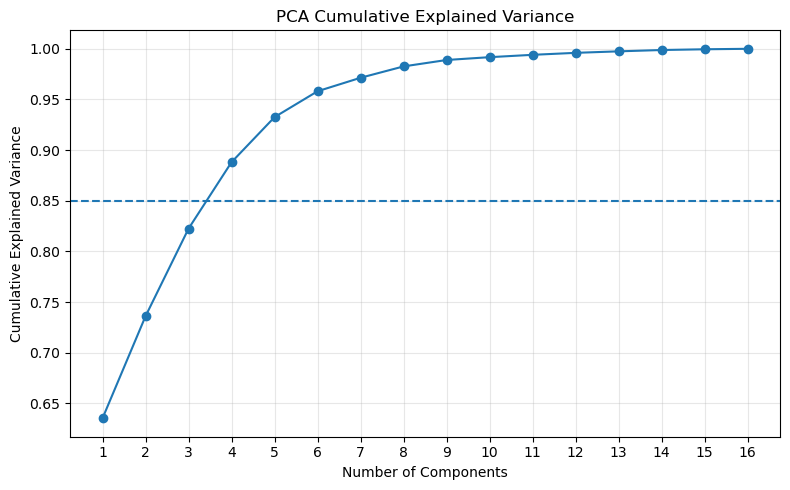


Saved:
 - vehicles_pca_features_v1.csv
 - pca_variance_summary_v1.csv
 - pca_loadings_v1.csv
 - pca_retained_info_v1.csv


In [4]:
# ============================================================
# Step 7: PCA dimensionality reduction
# Retain components explaining >= 85% variance
# Input: X_scaled_df from Step 6
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import display

print("=== Step 7: PCA Dimensionality Reduction ===")

# ------------------------------------------------------------
# 1. Use scaled dataframe from previous step
#    Assumes X_scaled_df already exists
# ------------------------------------------------------------
X_scaled_input = X_scaled_df.copy()

print(f"Scaled dataset shape: {X_scaled_input.shape}")

# Safety check
if X_scaled_input.isna().sum().sum() > 0:
    raise ValueError("X_scaled_df contains missing values. PCA cannot proceed.")

# Keep original feature names
original_feature_names = X_scaled_input.columns.tolist()

# Convert to array for PCA
X_scaled_array = X_scaled_input.values

# ------------------------------------------------------------
# 2. Fit full PCA first
# ------------------------------------------------------------
pca_full = PCA()
pca_full.fit(X_scaled_array)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# ------------------------------------------------------------
# 3. Determine number of components for >= 85% variance
# ------------------------------------------------------------
variance_threshold = 0.85
n_components = np.argmax(cum_var >= variance_threshold) + 1

print(f"\nNumber of components explaining >= {int(variance_threshold * 100)}% variance: {n_components}")

# ------------------------------------------------------------
# 4. Fit final PCA with selected number of components
# ------------------------------------------------------------
pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled_array)

X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=X_scaled_input.index
)

print(f"\nPCA dataset shape: {X_pca_df.shape}")

# ------------------------------------------------------------
# 5. Variance summary
# ------------------------------------------------------------
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained_Variance_Ratio": explained_var,
    "Cumulative_Explained_Variance": cum_var
})

print("\nPCA variance summary (first 10 PCs):")
display(pca_summary.head(10))

print("\nVariance explained by retained PCs:")
for i, val in enumerate(pca_final.explained_variance_ratio_, start=1):
    print(f"PC{i}: {val:.4f}")

if n_components >= 2:
    print(f"\nPC1 variance explained: {pca_final.explained_variance_ratio_[0]:.4f}")
    print(f"PC2 variance explained: {pca_final.explained_variance_ratio_[1]:.4f}")

# ------------------------------------------------------------
# 6. PCA loadings for interpretation
# ------------------------------------------------------------
pca_loadings = pd.DataFrame(
    pca_final.components_.T,
    index=original_feature_names,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

print("\nPCA loadings (first 10 features):")
display(pca_loadings.head(10))

# Optional: show strongest contributors to PC1 and PC2
for pc in pca_loadings.columns[:min(2, n_components)]:
    top_features = (
        pca_loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .index.tolist()
    )
    print(f"\nTop contributors to {pc}:")
    for feat in top_features:
        print(f" - {feat}: loading = {pca_loadings.loc[feat, pc]:.4f}")

# ------------------------------------------------------------
# 7. Plot cumulative explained variance
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(variance_threshold, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.xticks(range(1, len(cum_var) + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
X_pca_df.to_csv("vehicles_pca_features_v1.csv", index=False)
pca_summary.to_csv("pca_variance_summary_v1.csv", index=False)
pca_loadings.to_csv("pca_loadings_v1.csv")

retained_pc_info = pd.DataFrame({
    "Metric": [
        "Variance_Threshold",
        "Retained_Components",
        "PC1_Explained_Variance",
        "PC2_Explained_Variance" if n_components >= 2 else "PC2_Explained_Variance"
    ],
    "Value": [
        variance_threshold,
        n_components,
        pca_final.explained_variance_ratio_[0],
        pca_final.explained_variance_ratio_[1] if n_components >= 2 else np.nan
    ]
})
retained_pc_info.to_csv("pca_retained_info_v1.csv", index=False)

print("\nSaved:")
print(" - vehicles_pca_features_v1.csv")
print(" - pca_variance_summary_v1.csv")
print(" - pca_loadings_v1.csv")
print(" - pca_retained_info_v1.csv")

### 2.3 PCA Loadings Interpretation

Inspect which original features contribute most to each retained principal component, supporting downstream cluster interpretation.

In [5]:
# ============================================================
# Step 7B: Inspect PCA loadings
# Goal:
# 1) review which original features contribute most to each PC
# 2) support interpretation of PC1 and PC2 for reporting
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

print("=== Step 7B: PCA Loadings Interpretation ===")

# ------------------------------------------------------------
# 1. Use pca_loadings from Step 7 if it already exists
#    Otherwise rebuild it from pca_final and X_scaled_df
# ------------------------------------------------------------
if "pca_loadings" in globals():
    loadings = pca_loadings.copy()
else:
    feature_names = X_scaled_df.columns.tolist()
    loadings = pd.DataFrame(
        pca_final.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca_final.n_components_)]
    )

print("\nSigned PCA loadings:")
display(loadings)

# ------------------------------------------------------------
# 2. Absolute loadings for easier ranking
# ------------------------------------------------------------
abs_loadings = loadings.abs()

print("\nAbsolute PCA loadings:")
display(abs_loadings)

# ------------------------------------------------------------
# 3. Show top contributing features for each retained PC
# ------------------------------------------------------------
top_loading_rows = []

for pc in abs_loadings.columns:
    print(f"\nTop contributing features for {pc}:")
    
    top_feats = abs_loadings[pc].sort_values(ascending=False).head(10)
    
    pc_table = pd.DataFrame({
        "Feature": top_feats.index,
        "Abs_Loading": top_feats.values,
        "Signed_Loading": [loadings.loc[f, pc] for f in top_feats.index],
        "PC": pc
    })
    
    display(pc_table)
    top_loading_rows.append(pc_table)

# Combine all top contributors into one table
top_loadings_summary = pd.concat(top_loading_rows, ignore_index=True)

# ------------------------------------------------------------
# 4. Focus on PC1 and PC2 for executive interpretation
# ------------------------------------------------------------
pcs_to_focus = [pc for pc in ["PC1", "PC2"] if pc in loadings.columns]

for pc in pcs_to_focus:
    print(f"\nDetailed interpretation view for {pc}:")
    
    top_positive = loadings[pc].sort_values(ascending=False).head(8)
    top_negative = loadings[pc].sort_values(ascending=True).head(8)
    
    print("\nTop positive loadings:")
    display(top_positive.to_frame(name="Loading"))
    
    print("Top negative loadings:")
    display(top_negative.to_frame(name="Loading"))

# ------------------------------------------------------------
# 5. Save outputs
# ------------------------------------------------------------
loadings.to_csv("pca_loadings_v1.csv")
abs_loadings.to_csv("pca_abs_loadings_v1.csv")
top_loadings_summary.to_csv("pca_top_loadings_summary_v1.csv", index=False)

print("\nSaved:")
print(" - pca_loadings_v1.csv")
print(" - pca_abs_loadings_v1.csv")
print(" - pca_top_loadings_summary_v1.csv")

=== Step 7B: PCA Loadings Interpretation ===

Signed PCA loadings:


,PC1,PC2,PC3,PC4
Num_Gears,0.246749,-0.035478,0.144684,0.055172
Is_SUV,0.085226,-0.044965,-0.245982,0.746530
Is_Truck,0.001800,-0.409287,0.300211,-0.495776
Model_Year,-0.295735,0.087279,0.212931,0.102367
Engine_Size_L,0.228801,-0.302599,0.378455,0.197583
Motor_kW,-0.285952,-0.129762,-0.011104,0.031994
Fuel_Cons_Comb_L100km,0.271070,-0.196322,0.279324,0.167289
Elec_Cons_Comb_kWh100km,-0.298728,-0.160230,-0.073126,0.015858
Elec_Range_km,-0.298279,-0.161149,-0.074674,0.023708
Total_Range_km,-0.263445,0.191871,0.353756,0.122473



Absolute PCA loadings:


,PC1,PC2,PC3,PC4
Num_Gears,0.246749,0.035478,0.144684,0.055172
Is_SUV,0.085226,0.044965,0.245982,0.746530
Is_Truck,0.001800,0.409287,0.300211,0.495776
Model_Year,0.295735,0.087279,0.212931,0.102367
Engine_Size_L,0.228801,0.302599,0.378455,0.197583
Motor_kW,0.285952,0.129762,0.011104,0.031994
Fuel_Cons_Comb_L100km,0.271070,0.196322,0.279324,0.167289
Elec_Cons_Comb_kWh100km,0.298728,0.160230,0.073126,0.015858
Elec_Range_km,0.298279,0.161149,0.074674,0.023708
Total_Range_km,0.263445,0.191871,0.353756,0.122473



Top contributing features for PC1:


...


Detailed interpretation view for PC2:

Top positive loadings:


,Loading
Fuel_Efficiency_Index,0.507233
Electric_Efficiency_Index,0.456540
CO2_per_L_engine,0.216547
Total_Range_km,0.191871
Model_Year,0.087279
City_Hwy_Fuel_Ratio,0.070227
Num_Gears,-0.035478
Is_SUV,-0.044965


Top negative loadings:


,Loading
Is_Truck,-0.409287
Engine_Size_L,-0.302599
CO2_Emissions_g_km,-0.250927
Fuel_Cons_Comb_L100km,-0.196322
Elec_Range_km,-0.161149
Elec_Cons_Comb_kWh100km,-0.160230
Motor_kW,-0.129762
Range_per_ChargeHour,-0.075361



Saved:
 - pca_loadings_v1.csv
 - pca_abs_loadings_v1.csv
 - pca_top_loadings_summary_v1.csv


---
## Part 3 · Clustering (K = 8, Recommended)

### 3.1 K Selection — Multi-Metric Evaluation

Evaluate KMeans across K = 2 … 10 using Silhouette, Davies–Bouldin, and Calinski–Harabasz scores. A rank-based summary is used to select the best K.

> The recommended K from this step is **K = 8**.

=== Step 8A: K-Means Evaluation Across K ===
Input shape for clustering: (7870, 4)

K evaluation summary:


,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Min_Cluster_Size,Max_Cluster_Size,Rank_Silhouette,Rank_Davies_Bouldin,Rank_Calinski_Harabasz,Rank_Sum
0,8,5089.185970,0.596391,0.537086,23558.923758,390,1940,3.0,4.0,3.0,10.0
1,2,38148.304260,0.709988,0.458138,15198.158309,1358,6512,1.0,2.0,8.0,11.0
2,9,4275.547929,0.577245,0.515738,24720.637333,125,1953,6.0,3.0,2.0,11.0
3,3,23238.104826,0.699257,0.433086,14997.109761,390,6285,2.0,1.0,9.0,12.0
4,10,3522.504807,0.569622,0.578770,26854.430438,125,1949,7.0,5.0,1.0,13.0
5,7,5976.317532,0.592478,0.587274,23213.589234,390,2011,4.0,6.0,4.0,14.0
6,6,7541.066742,0.580465,0.608732,21752.604232,390,2128,5.0,7.0,5.0,17.0
7,5,9880.979565,0.567230,0.614685,20288.649855,390,3152,8.0,8.0,6.0,22.0
8,4,15089.455545,0.496686,0.732251,16811.248976,390,4395,9.0,9.0,7.0,25.0



Cluster sizes by K:


,K,Cluster,Size
0,2,0,6512
1,2,1,1358
2,3,0,1195
3,3,1,6285
4,3,2,390
5,4,0,4395
6,4,1,1195
7,4,2,1890
8,4,3,390
9,5,0,1604



Best K by Silhouette only: 2
Best K by combined rank summary: 8
Recommended K for next step: 8


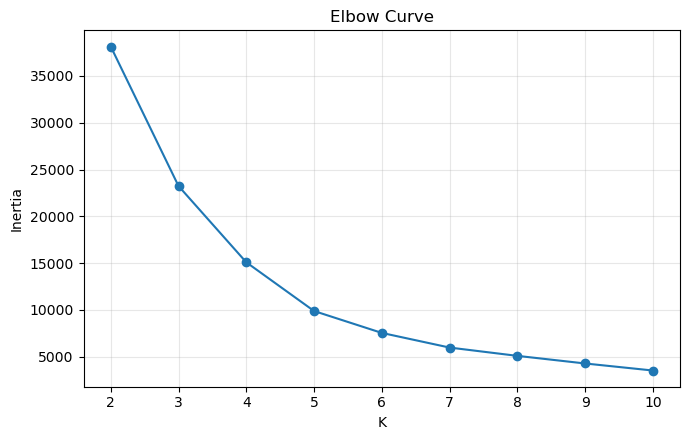

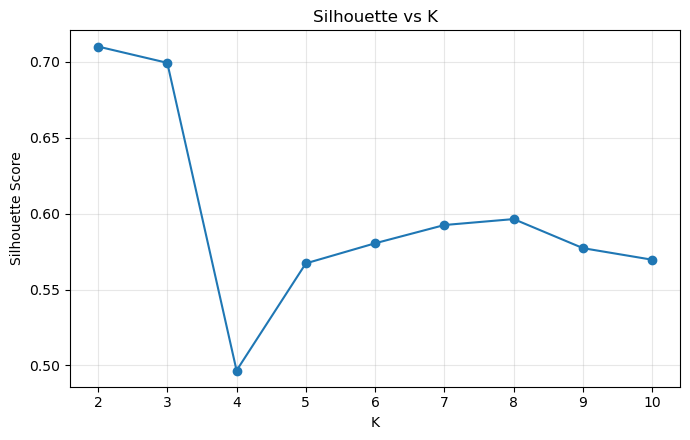

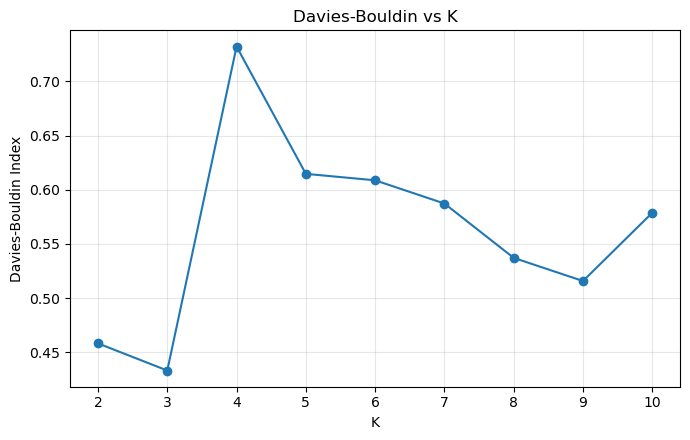

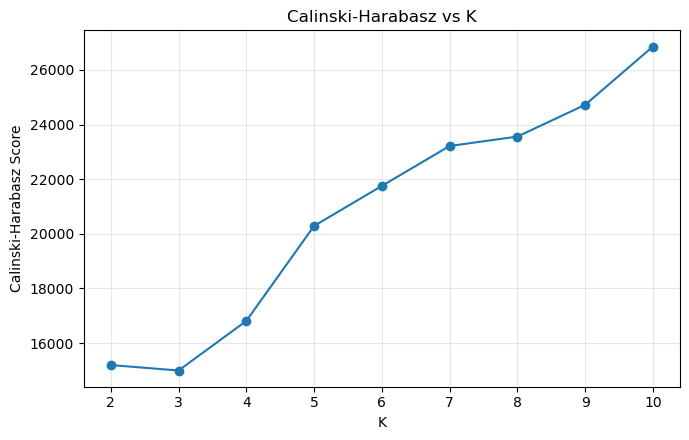


Saved:
 - kmeans_k_evaluation_v1.csv
 - kmeans_cluster_sizes_by_k_v1.csv


In [6]:
# ============================================================
# Step 8A: Evaluate K-Means across a range of K values
# Input: X_pca_df from Step 7
# Goal:
# 1) compare clustering quality across K
# 2) avoid relying on a single metric only
# 3) inspect whether smaller K is consistently preferred
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from IPython.display import display

print("=== Step 8A: K-Means Evaluation Across K ===")

# ------------------------------------------------------------
# 1. Input data
# ------------------------------------------------------------
X_cluster_input = X_pca_df.copy()

print(f"Input shape for clustering: {X_cluster_input.shape}")

# ------------------------------------------------------------
# 2. Evaluate a wider and more standard K range
# ------------------------------------------------------------
K_RANGE = range(2, 11)
results = []
cluster_size_tables = []

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_cluster_input)

    inertia = kmeans.inertia_
    sil = silhouette_score(X_cluster_input, labels)
    db = davies_bouldin_score(X_cluster_input, labels)
    ch = calinski_harabasz_score(X_cluster_input, labels)

    # Cluster size distribution
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    min_cluster_size = int(cluster_sizes.min())
    max_cluster_size = int(cluster_sizes.max())

    results.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette": sil,
        "Davies_Bouldin": db,
        "Calinski_Harabasz": ch,
        "Min_Cluster_Size": min_cluster_size,
        "Max_Cluster_Size": max_cluster_size
    })

    cluster_size_df = pd.DataFrame({
        "K": k,
        "Cluster": cluster_sizes.index,
        "Size": cluster_sizes.values
    })
    cluster_size_tables.append(cluster_size_df)

k_eval = pd.DataFrame(results)

# ------------------------------------------------------------
# 3. Rank-based summary
#    Higher is better for Silhouette and CH
#    Lower is better for DBI
# ------------------------------------------------------------
k_eval["Rank_Silhouette"] = k_eval["Silhouette"].rank(ascending=False, method="min")
k_eval["Rank_Davies_Bouldin"] = k_eval["Davies_Bouldin"].rank(ascending=True, method="min")
k_eval["Rank_Calinski_Harabasz"] = k_eval["Calinski_Harabasz"].rank(ascending=False, method="min")

k_eval["Rank_Sum"] = (
    k_eval["Rank_Silhouette"] +
    k_eval["Rank_Davies_Bouldin"] +
    k_eval["Rank_Calinski_Harabasz"]
)

k_eval = k_eval.sort_values(["Rank_Sum", "Silhouette"], ascending=[True, False]).reset_index(drop=True)

print("\nK evaluation summary:")
display(k_eval)

cluster_size_all = pd.concat(cluster_size_tables, ignore_index=True)

print("\nCluster sizes by K:")
display(cluster_size_all)

# ------------------------------------------------------------
# 4. Choose candidate K values
# ------------------------------------------------------------
best_k_silhouette = int(k_eval.loc[k_eval["Rank_Silhouette"].idxmin(), "K"])
best_k_rank_sum = int(k_eval.loc[k_eval["Rank_Sum"].idxmin(), "K"])

print(f"\nBest K by Silhouette only: {best_k_silhouette}")
print(f"Best K by combined rank summary: {best_k_rank_sum}")

# Use combined-rank best as a more balanced default
best_k = best_k_rank_sum
print(f"Recommended K for next step: {best_k}")

# ------------------------------------------------------------
# 5. Plot evaluation curves
# ------------------------------------------------------------
plot_df = k_eval.sort_values("K").copy()

plt.figure(figsize=(7, 4.5))
plt.plot(plot_df["K"], plot_df["Inertia"], marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.xticks(list(K_RANGE))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(plot_df["K"], plot_df["Silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs K")
plt.xticks(list(K_RANGE))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(plot_df["K"], plot_df["Davies_Bouldin"], marker="o")
plt.xlabel("K")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin vs K")
plt.xticks(list(K_RANGE))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(plot_df["K"], plot_df["Calinski_Harabasz"], marker="o")
plt.xlabel("K")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz vs K")
plt.xticks(list(K_RANGE))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Save outputs
# ------------------------------------------------------------
k_eval.to_csv("kmeans_k_evaluation_v1.csv", index=False)
cluster_size_all.to_csv("kmeans_cluster_sizes_by_k_v1.csv", index=False)

print("\nSaved:")
print(" - kmeans_k_evaluation_v1.csv")
print(" - kmeans_cluster_sizes_by_k_v1.csv")

### 3.2 Model Comparison at K = 8

Compare KMeans, Hierarchical (Ward), and Gaussian Mixture at the recommended K = 8, and select the best model by combined metric ranking.

In [7]:
# ============================================================
# Step 8B: Compare clustering models using the selected K
# Input:
# - X_pca_df from Step 7
# - best_k from Step 8A
# Goal:
# 1) compare different clustering algorithms fairly
# 2) use the same number of clusters/components across models
# 3) select the best model based on multiple internal metrics
# ============================================================

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from IPython.display import display

print("=== Step 8B: Compare Clustering Models ===")

# ------------------------------------------------------------
# 1. Input data
# ------------------------------------------------------------
X_model_input = X_pca_df.copy()

print(f"Input shape for model comparison: {X_model_input.shape}")
print(f"Using best_k = {best_k}")

model_results = []
cluster_size_tables = []

# ------------------------------------------------------------
# 2. KMeans
# ------------------------------------------------------------
km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
km_labels = km.fit_predict(X_model_input)

model_results.append({
    "Model": "KMeans",
    "Silhouette": silhouette_score(X_model_input, km_labels),
    "Davies_Bouldin": davies_bouldin_score(X_model_input, km_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_model_input, km_labels),
    "Labels": km_labels
})

# ------------------------------------------------------------
# 3. Hierarchical (Ward linkage)
# ------------------------------------------------------------
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_model_input)

model_results.append({
    "Model": "Hierarchical",
    "Silhouette": silhouette_score(X_model_input, agg_labels),
    "Davies_Bouldin": davies_bouldin_score(X_model_input, agg_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_model_input, agg_labels),
    "Labels": agg_labels
})

# ------------------------------------------------------------
# 4. Gaussian Mixture
# ------------------------------------------------------------
gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X_model_input)

model_results.append({
    "Model": "GaussianMixture",
    "Silhouette": silhouette_score(X_model_input, gmm_labels),
    "Davies_Bouldin": davies_bouldin_score(X_model_input, gmm_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_model_input, gmm_labels),
    "Labels": gmm_labels
})

# ------------------------------------------------------------
# 5. Build evaluation table
# ------------------------------------------------------------
model_eval = pd.DataFrame([
    {k: v for k, v in r.items() if k != "Labels"}
    for r in model_results
])

# Rank-based summary
model_eval["Rank_Silhouette"] = model_eval["Silhouette"].rank(ascending=False, method="min")
model_eval["Rank_Davies_Bouldin"] = model_eval["Davies_Bouldin"].rank(ascending=True, method="min")
model_eval["Rank_Calinski_Harabasz"] = model_eval["Calinski_Harabasz"].rank(ascending=False, method="min")

model_eval["Rank_Sum"] = (
    model_eval["Rank_Silhouette"] +
    model_eval["Rank_Davies_Bouldin"] +
    model_eval["Rank_Calinski_Harabasz"]
)

# ------------------------------------------------------------
# 6. Cluster size distribution for each model
# ------------------------------------------------------------
for result in model_results:
    labels = result["Labels"]
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    size_df = pd.DataFrame({
        "Model": result["Model"],
        "Cluster": cluster_sizes.index,
        "Size": cluster_sizes.values
    })
    cluster_size_tables.append(size_df)

    model_eval.loc[model_eval["Model"] == result["Model"], "Min_Cluster_Size"] = int(cluster_sizes.min())
    model_eval.loc[model_eval["Model"] == result["Model"], "Max_Cluster_Size"] = int(cluster_sizes.max())

cluster_sizes_all_models = pd.concat(cluster_size_tables, ignore_index=True)

# Sort final table
model_eval = model_eval.sort_values(
    ["Rank_Sum", "Silhouette"],
    ascending=[True, False]
).reset_index(drop=True)

print("\nModel evaluation summary:")
display(model_eval)

print("\nCluster sizes by model:")
display(cluster_sizes_all_models)

# ------------------------------------------------------------
# 7. Select best model
# ------------------------------------------------------------
best_model_idx = model_eval["Rank_Sum"].idxmin()
best_model_name = model_eval.loc[best_model_idx, "Model"]

best_labels = None
for r in model_results:
    if r["Model"] == best_model_name:
        best_labels = r["Labels"]
        break

print(f"\nBest model based on combined metric ranking: {best_model_name}")

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
model_eval.to_csv("clustering_model_comparison_v1.csv", index=False)
cluster_sizes_all_models.to_csv("clustering_model_cluster_sizes_v1.csv", index=False)

print("\nSaved:")
print(" - clustering_model_comparison_v1.csv")
print(" - clustering_model_cluster_sizes_v1.csv")

=== Step 8B: Compare Clustering Models ===
Input shape for model comparison: (7870, 4)
Using best_k = 8

Model evaluation summary:


,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz,Rank_Silhouette,Rank_Davies_Bouldin,Rank_Calinski_Harabasz,Rank_Sum,Min_Cluster_Size,Max_Cluster_Size
0,Hierarchical,0.598527,0.519847,23168.639754,1.0,1.0,2.0,4.0,391.0,2074.0
1,KMeans,0.596391,0.537086,23558.923758,2.0,2.0,1.0,5.0,390.0,1940.0
2,GaussianMixture,0.489599,0.863757,17002.342520,3.0,3.0,3.0,9.0,125.0,2072.0



Cluster sizes by model:


,Model,Cluster,Size
0,KMeans,0,608
1,KMeans,1,1195
2,KMeans,2,1382
3,KMeans,3,390
4,KMeans,4,778
5,KMeans,5,737
6,KMeans,6,1940
7,KMeans,7,840
8,Hierarchical,0,1195
9,Hierarchical,1,826



Best model based on combined metric ranking: Hierarchical

Saved:
 - clustering_model_comparison_v1.csv
 - clustering_model_cluster_sizes_v1.csv


---
## Part 4 · Cluster Visualisation and Diagnostics (K = 8)

### 4.1 PCA Cluster Plot

=== Step 9A: PCA Cluster Plot ===
Plot dataframe shape: (7870, 5)
Number of clusters in best_labels: 8


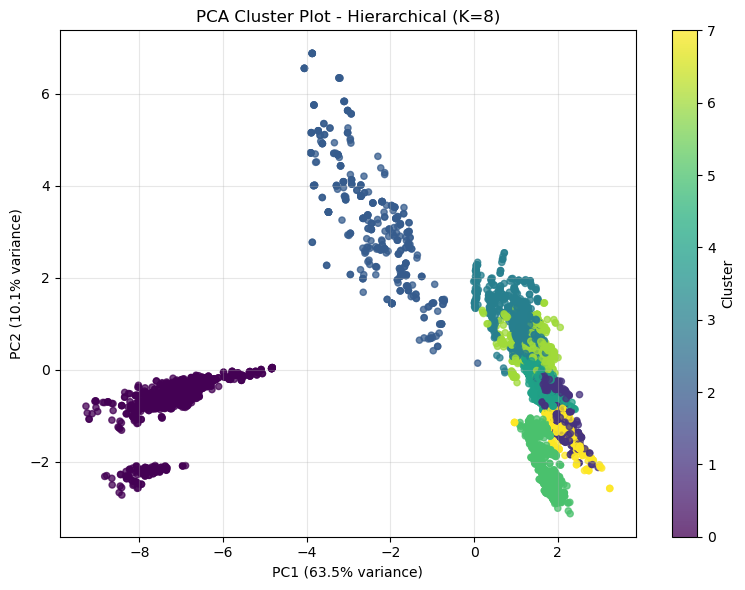


Saved:
 - pca_cluster_plot_data_v1.csv


In [8]:
# ============================================================
# Step 9A: PCA cluster plot for the selected final model
# Input:
# - X_pca_df
# - best_labels
# - best_model_name
# - best_k
# - pca_final
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

print("=== Step 9A: PCA Cluster Plot ===")

# ------------------------------------------------------------
# 1. Build plotting dataframe
# ------------------------------------------------------------
plot_df = X_pca_df.copy()
plot_df["cluster"] = best_labels

print(f"Plot dataframe shape: {plot_df.shape}")
print(f"Number of clusters in best_labels: {plot_df['cluster'].nunique()}")

# ------------------------------------------------------------
# 2. PCA scatter plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster"],
    s=20,
    alpha=0.75
)

pc1_var = pca_final.explained_variance_ratio_[0] * 100
pc2_var = pca_final.explained_variance_ratio_[1] * 100 if pca_final.n_components_ >= 2 else 0

plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)")
plt.title(f"PCA Cluster Plot - {best_model_name} (K={best_k})")
plt.colorbar(scatter, label="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Save plot dataframe if needed
# ------------------------------------------------------------
plot_df.to_csv("pca_cluster_plot_data_v1.csv", index=False)

print("\nSaved:")
print(" - pca_cluster_plot_data_v1.csv")

### 4.2 Attach Cluster Labels to Original Features

In [9]:
# ============================================================
# Step 9B: Attach final cluster labels back to the selected original features
# Input:
# - df_selected_v1
# - best_labels
# ============================================================

import pandas as pd
from IPython.display import display

print("=== Step 9B: Attach Cluster Labels to Original Features ===")

# ------------------------------------------------------------
# 1. Build labelled feature dataframe
# ------------------------------------------------------------
df_clustered_v1 = df_selected_v1.copy()
df_clustered_v1["cluster"] = best_labels

print(f"df_clustered_v1 shape: {df_clustered_v1.shape}")
print("\nCluster counts:")
display(df_clustered_v1["cluster"].value_counts().sort_index().to_frame(name="Count"))

# ------------------------------------------------------------
# 2. Save labelled dataset
# ------------------------------------------------------------
df_clustered_v1.to_csv("vehicles_with_clusters_selected_features_v1.csv", index=False)

print("\nSaved:")
print(" - vehicles_with_clusters_selected_features_v1.csv")

=== Step 9B: Attach Cluster Labels to Original Features ===
df_clustered_v1 shape: (7870, 17)

Cluster counts:


,Count
cluster,
0,1195
1,826
2,391
3,2074
4,1485
5,608
6,792
7,499



Saved:
 - vehicles_with_clusters_selected_features_v1.csv


### 4.3 Cluster Mean Comparison (Bar Charts)

=== Step 9C: Cluster Mean Comparison ===
Features selected for cluster mean plots:
 - Engine_Size_L
 - Motor_kW
 - CO2_Emissions_g_km
 - Elec_Range_km

Cluster means:


,Engine_Size_L,Motor_kW,CO2_Emissions_g_km,Elec_Range_km
cluster,,,,
0,0.000000,340.338912,0.000000,447.149791
1,4.127119,0.000000,300.292978,0.000000
2,2.342711,100.030691,102.324808,46.503836
3,1.940501,0.000000,195.035680,0.000000
4,3.539865,0.000000,264.386532,0.000000
5,4.170230,0.000000,296.231908,0.000000
6,2.212374,0.000000,224.255051,0.000000
7,5.815631,0.661323,352.913828,0.048096


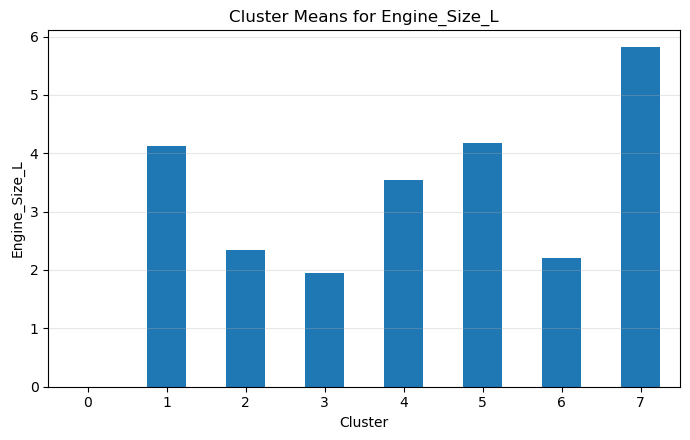

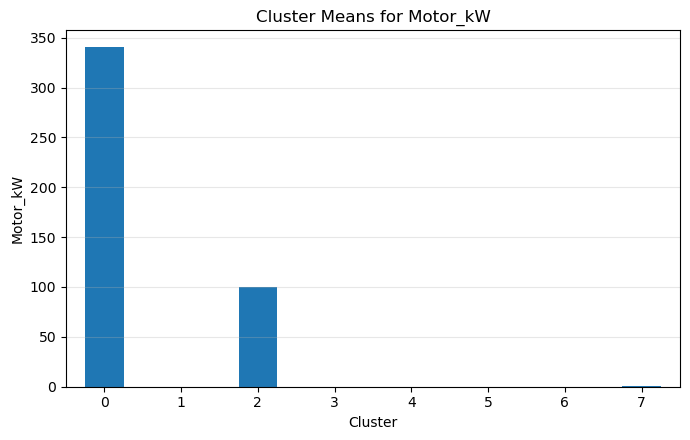

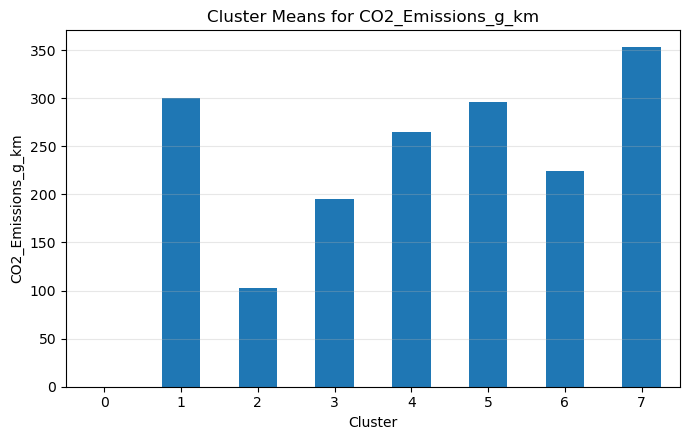

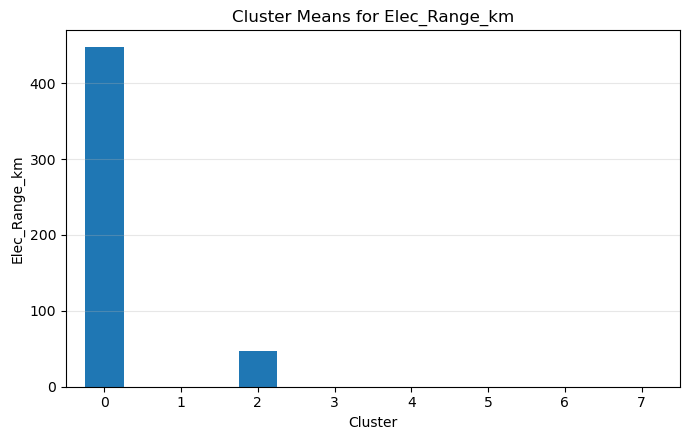


Saved:
 - cluster_means_key_features_v1.csv


In [10]:
# ============================================================
# Step 9C: Cluster mean comparison bar charts
# Goal:
# show how clusters differ on key original features
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=== Step 9C: Cluster Mean Comparison ===")

# ------------------------------------------------------------
# 1. Select key features for interpretation
# ------------------------------------------------------------
features_to_plot = [
    "Engine_Size_L",
    "Motor_kW",
    "CO2_Emissions_g_km",
    "Elec_Range_km"
]

features_to_plot = [c for c in features_to_plot if c in df_clustered_v1.columns]

print("Features selected for cluster mean plots:")
for c in features_to_plot:
    print(" -", c)

# ------------------------------------------------------------
# 2. Compute cluster means
# ------------------------------------------------------------
cluster_means = df_clustered_v1.groupby("cluster")[features_to_plot].mean()

print("\nCluster means:")
display(cluster_means)

cluster_means.to_csv("cluster_means_key_features_v1.csv")

# ------------------------------------------------------------
# 3. Plot one bar chart per feature
# ------------------------------------------------------------
for feat in features_to_plot:
    plt.figure(figsize=(7, 4.5))
    cluster_means[feat].plot(kind="bar")
    plt.title(f"Cluster Means for {feat}")
    plt.xlabel("Cluster")
    plt.ylabel(feat)
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nSaved:")
print(" - cluster_means_key_features_v1.csv")

### 4.4 Original Feature Scatter Plots by Cluster

=== Step 9D: Original Feature Scatter Plots by Cluster ===


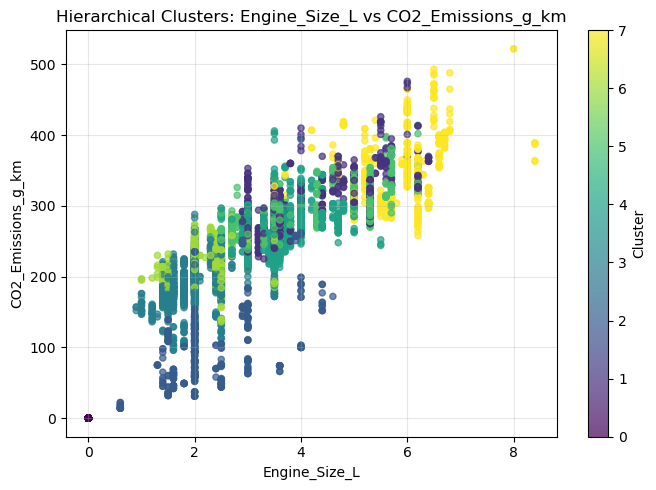

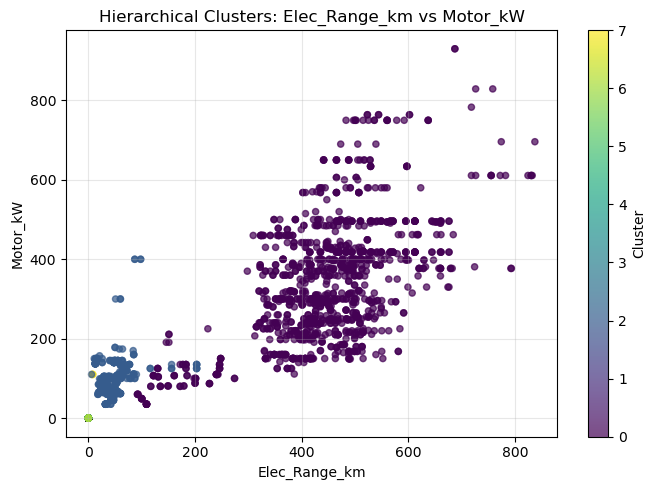

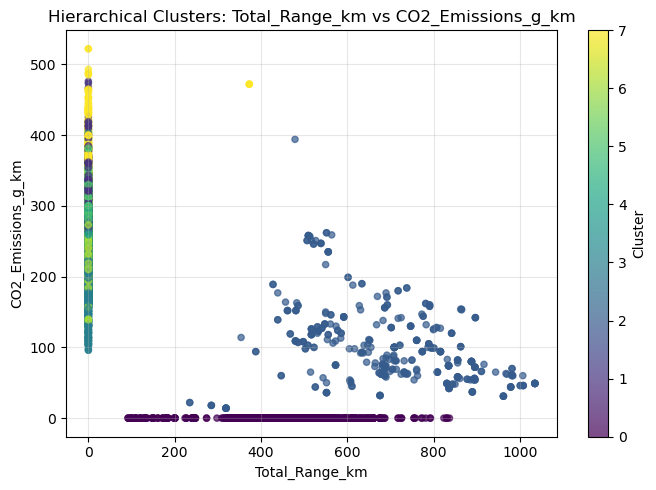

In [11]:
# ============================================================
# Step 9D: Original feature scatter plots by cluster
# Goal:
# visualise cluster separation in interpretable original feature space
# ============================================================

import matplotlib.pyplot as plt

print("=== Step 9D: Original Feature Scatter Plots by Cluster ===")

# ------------------------------------------------------------
# 1. Scatter plot helper
# ------------------------------------------------------------
def plot_cluster_scatter(df_input, x_col, y_col, cluster_col="cluster", title=None):
    plt.figure(figsize=(7, 5))
    
    scatter = plt.scatter(
        df_input[x_col],
        df_input[y_col],
        c=df_input[cluster_col],
        s=20,
        alpha=0.7
    )
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title if title else f"{x_col} vs {y_col} by Cluster")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 2. Plot selected feature pairs
# ------------------------------------------------------------
candidate_pairs = [
    ("Engine_Size_L", "CO2_Emissions_g_km"),
    ("Elec_Range_km", "Motor_kW"),
    ("Total_Range_km", "CO2_Emissions_g_km")
]

for x_col, y_col in candidate_pairs:
    if x_col in df_clustered_v1.columns and y_col in df_clustered_v1.columns:
        plot_cluster_scatter(
            df_clustered_v1,
            x_col,
            y_col,
            title=f"{best_model_name} Clusters: {x_col} vs {y_col}"
        )

### 4.5 Scatter Plots with Cluster Mean Centres

=== Step 9E: Scatter Plots with Cluster Mean Centres ===


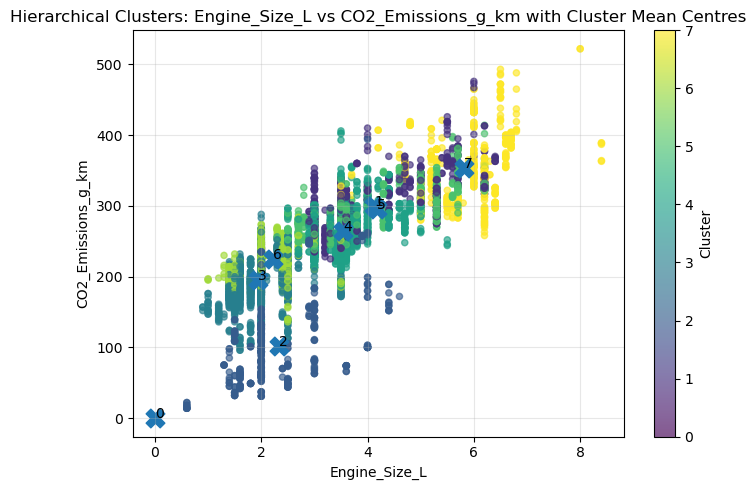

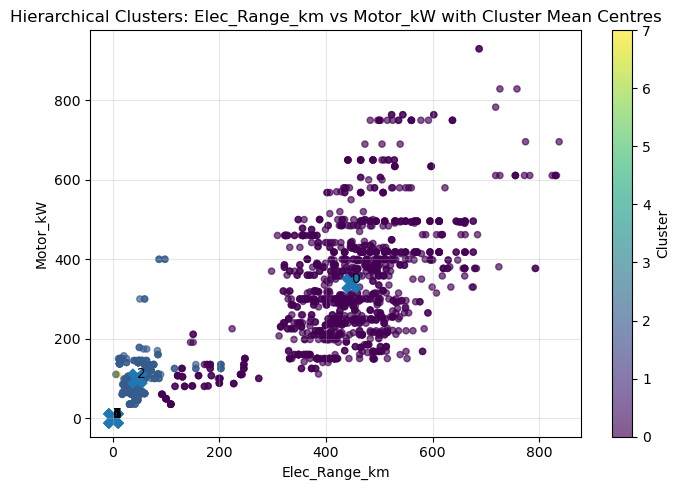

In [12]:
# ============================================================
# Step 9E: Original feature scatter plots with cluster mean centres
# For hierarchical clustering, these are cluster mean centres
# rather than true model centroids
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=== Step 9E: Scatter Plots with Cluster Mean Centres ===")

def plot_scatter_with_cluster_centres(df_input, x_col, y_col, cluster_col="cluster", title=None):
    plt.figure(figsize=(7, 5))

    scatter = plt.scatter(
        df_input[x_col],
        df_input[y_col],
        c=df_input[cluster_col],
        s=20,
        alpha=0.65
    )

    # cluster mean centres
    centres = df_input.groupby(cluster_col)[[x_col, y_col]].mean()

    plt.scatter(
        centres[x_col],
        centres[y_col],
        marker="X",
        s=180
    )

    for cluster_id, row in centres.iterrows():
        plt.text(row[x_col], row[y_col], str(cluster_id), fontsize=10)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title if title else f"{x_col} vs {y_col} with Cluster Mean Centres")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example plots
pairs_with_centres = [
    ("Engine_Size_L", "CO2_Emissions_g_km"),
    ("Elec_Range_km", "Motor_kW")
]

for x_col, y_col in pairs_with_centres:
    if x_col in df_clustered_v1.columns and y_col in df_clustered_v1.columns:
        plot_scatter_with_cluster_centres(
            df_clustered_v1,
            x_col,
            y_col,
            title=f"{best_model_name} Clusters: {x_col} vs {y_col} with Cluster Mean Centres"
        )

### 4.6 EV-Dominance Diagnostic

Check whether the clustering structure is mainly separating BEVs from non-BEVs, or whether finer ICE/hybrid distinctions are also captured.

In [13]:
# ============================================================
# Step 9F: Diagnose whether clusters are dominated by EV vs non-EV structure
# Goal:
# check whether current clustering is mainly separating BEVs
# ============================================================

import pandas as pd
from IPython.display import display

print("=== Step 9F: Diagnose EV-dominated Clustering Structure ===")

# ------------------------------------------------------------
# 1. Work on the clustered original-feature dataframe
#    Assumes df_clustered_v1 already exists
# ------------------------------------------------------------
df_diag = df_clustered_v1.copy()

# ------------------------------------------------------------
# 2. Define a simple BEV-like rule
#    This is only a diagnostic proxy, not a final label
# ------------------------------------------------------------
df_diag["BEV_like"] = (
    (df_diag["Engine_Size_L"] == 0) &
    (df_diag["CO2_Emissions_g_km"] == 0) &
    (df_diag["Elec_Range_km"] > 0)
).astype(int)

# Optional broader EV-like flag
df_diag["EV_or_Electrified_like"] = (
    (df_diag["Elec_Range_km"] > 0) | (df_diag["Motor_kW"] > 0)
).astype(int)

# ------------------------------------------------------------
# 3. Cluster-level composition
# ------------------------------------------------------------
cluster_diag = df_diag.groupby("cluster").agg(
    Count=("cluster", "size"),
    BEV_like_Count=("BEV_like", "sum"),
    EV_or_Electrified_Count=("EV_or_Electrified_like", "sum"),
    Mean_Engine_Size_L=("Engine_Size_L", "mean"),
    Mean_Motor_kW=("Motor_kW", "mean"),
    Mean_CO2_Emissions=("CO2_Emissions_g_km", "mean"),
    Mean_Elec_Range_km=("Elec_Range_km", "mean")
).reset_index()

cluster_diag["BEV_like_Rate"] = cluster_diag["BEV_like_Count"] / cluster_diag["Count"]
cluster_diag["EV_or_Electrified_Rate"] = cluster_diag["EV_or_Electrified_Count"] / cluster_diag["Count"]

print("\nCluster diagnostic summary:")
display(cluster_diag.sort_values("BEV_like_Rate", ascending=False))

# ------------------------------------------------------------
# 4. Cross-tab view
# ------------------------------------------------------------
bev_crosstab = pd.crosstab(
    df_diag["cluster"],
    df_diag["BEV_like"],
    normalize="index"
).rename(columns={0: "Non_BEV_like_Rate", 1: "BEV_like_Rate"})

print("\nCluster vs BEV-like composition:")
display(bev_crosstab)

# ------------------------------------------------------------
# 5. Save outputs
# ------------------------------------------------------------
cluster_diag.to_csv("cluster_ev_diagnostic_summary_v1.csv", index=False)
bev_crosstab.to_csv("cluster_bev_like_crosstab_v1.csv")

print("\nSaved:")
print(" - cluster_ev_diagnostic_summary_v1.csv")
print(" - cluster_bev_like_crosstab_v1.csv")

=== Step 9F: Diagnose EV-dominated Clustering Structure ===

Cluster diagnostic summary:


,cluster,Count,BEV_like_Count,EV_or_Electrified_Count,Mean_Engine_Size_L,Mean_Motor_kW,Mean_CO2_Emissions,Mean_Elec_Range_km,BEV_like_Rate,EV_or_Electrified_Rate
0,0,1195,1195,1195,0.000000,340.338912,0.000000,447.149791,1.0,1.000000
1,1,826,0,0,4.127119,0.000000,300.292978,0.000000,0.0,0.000000
2,2,391,0,391,2.342711,100.030691,102.324808,46.503836,0.0,1.000000
3,3,2074,0,0,1.940501,0.000000,195.035680,0.000000,0.0,0.000000
4,4,1485,0,0,3.539865,0.000000,264.386532,0.000000,0.0,0.000000
5,5,608,0,0,4.170230,0.000000,296.231908,0.000000,0.0,0.000000
6,6,792,0,0,2.212374,0.000000,224.255051,0.000000,0.0,0.000000
7,7,499,0,3,5.815631,0.661323,352.913828,0.048096,0.0,0.006012



Cluster vs BEV-like composition:


BEV_like,Non_BEV_like_Rate,BEV_like_Rate
cluster,,
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,1.0,0.0
6,1.0,0.0
7,1.0,0.0



Saved:
 - cluster_ev_diagnostic_summary_v1.csv
 - cluster_bev_like_crosstab_v1.csv


---
## Part 5 · Cluster Interpretation and Naming (K = 8)

### 5.1 Interpretation Summary Table

In [14]:
# ============================================================
# Step 11A: Build cluster interpretation summary table
# Goal:
# create a compact summary to support cluster naming
# ============================================================

import pandas as pd
from IPython.display import display

print("=== Step 11A: Cluster Interpretation Summary ===")

# ------------------------------------------------------------
# 1. Input
#    Assumes df_clustered_v1 exists (main route result)
# ------------------------------------------------------------
df_interpret = df_clustered_v1.copy()

# ------------------------------------------------------------
# 2. Features to summarise
# ------------------------------------------------------------
summary_features = [
    "Engine_Size_L",
    "Motor_kW",
    "CO2_Emissions_g_km",
    "Elec_Range_km",
    "Total_Range_km",
    "Num_Gears",
    "Fuel_Efficiency_Index",
    "Electric_Efficiency_Index",
    "Is_SUV",
    "Is_Truck"
]

summary_features = [c for c in summary_features if c in df_interpret.columns]

print("Features used for interpretation summary:")
for c in summary_features:
    print(" -", c)

# ------------------------------------------------------------
# 3. Cluster summary
# ------------------------------------------------------------
cluster_summary_interpret = df_interpret.groupby("cluster")[summary_features].agg(["mean", "median"])
cluster_counts = df_interpret["cluster"].value_counts().sort_index().to_frame(name="Count")

print("\nCluster counts:")
display(cluster_counts)

print("\nCluster interpretation summary:")
display(cluster_summary_interpret)

# ------------------------------------------------------------
# 4. Flatten columns for saving
# ------------------------------------------------------------
cluster_summary_flat = cluster_summary_interpret.copy()
cluster_summary_flat.columns = [
    f"{col}_{stat}" for col, stat in cluster_summary_flat.columns
]
cluster_summary_flat = cluster_summary_flat.reset_index()

cluster_summary_flat = cluster_summary_flat.merge(
    cluster_counts.reset_index().rename(columns={"index": "cluster"}),
    on="cluster",
    how="left"
)

cluster_summary_flat.to_csv("cluster_interpretation_summary_v1.csv", index=False)

print("\nSaved:")
print(" - cluster_interpretation_summary_v1.csv")

=== Step 11A: Cluster Interpretation Summary ===
Features used for interpretation summary:
 - Engine_Size_L
 - Motor_kW
 - CO2_Emissions_g_km
 - Elec_Range_km
 - Total_Range_km
 - Num_Gears
 - Fuel_Efficiency_Index
 - Electric_Efficiency_Index
 - Is_SUV
 - Is_Truck

Cluster counts:


,Count
cluster,
0,1195
1,826
2,391
3,2074
4,1485
5,608
6,792
7,499



Cluster interpretation summary:


Engine_Size_L           Motor_kW        CO2_Emissions_g_km         \
                 mean median        mean median               mean median   
cluster                                                                     
0            0.000000    0.0  340.338912  330.0           0.000000    0.0   
1            4.127119    3.6    0.000000    0.0         300.292978  294.0   
2            2.342711    2.0  100.030691   96.0         102.324808   94.0   
3            1.940501    2.0    0.000000    0.0         195.035680  197.0   
4            3.539865    3.5    0.000000    0.0         264.386532  260.0   
5            4.170230    4.0    0.000000    0.0         296.231908  292.0   
6            2.212374    2.0    0.000000    0.0         224.255051  225.0   
7            5.815631    6.0    0.661323    0.0         352.913828  348.0   

        Elec_Range_km        Total_Range_km        Num_Gears         \
                 mean median           mean median      mean median   
cluster                                                               
0          447.149791  454.0     447.149791  454.0  1.046862    1.0   
1            0.000000    0.0       0.000000    0.0  7.076271    7.0   
2           46.503836   42.0     698.608696  702.0  5.608696    8.0   
3            0.000000    0.0       0.000000    0.0  5.901157    6.0   
4            0.000000    0.0       0.000000    0.0  7.218855    7.0   
5            0.000000    0.0       0.000000    0.0  7.024671    6.0   
6            0.000000    0.0       0.000000    0.0  6.263889    6.0   
7            0.048096    0.0       2.242485    0.0  6.955912    7.0   

        Fuel_Efficiency_Index            Electric_Efficiency_Index             \
                         mean     median                      mean     median   
cluster                                                                         
0                    0.000000   0.000000                  4.468959   4.385965   
1                    7.604610   7.692308                  0.000000   0.000000   
2                   12.373084  11.363636                 30.436208  29.411765   
3                   12.245286  11.904762                  0.000000   0.000000   
4                    8.775358   8.849558                  0.000000   0.000000   
5                    7.669052   7.692308                  0.000000   0.000000   
6                   10.548430  10.416667                  0.000000   0.000000   
7                    6.583486   6.622517                  0.057808   0.000000   

        Is_SUV         Is_Truck         
          mean median      mean median  
cluster                                 
0          0.0    0.0  0.104603    0.0  
1          1.0    1.0  0.000000    0.0  
2          0.0    0.0  0.000000    0.0  
3          0.0    0.0  0.000000    0.0  
4          0.0    0.0  0.000000    0.0  
5          0.0    0.0  1.000000    1.0  
6          1.0    1.0  0.000000    0.0  
7          0.0    0.0  0.000000    0.0


Saved:
 - cluster_interpretation_summary_v1.csv


### 5.2 Final Cluster Naming

In [15]:
# ============================================================
# Step 11B: Final cluster naming table
# Based on the interpreted cluster profiles from Step 11A
# ============================================================

import pandas as pd
from IPython.display import display

print("=== Step 11B: Final Cluster Naming Table ===")

cluster_naming_table = pd.DataFrame({
    "cluster": [0, 1, 2, 3, 4, 5, 6, 7],
    "Commercial_Label": [
        "Zero-Emission Leaders",
        "Large SUV Emitters",
        "Electrified Transition Fleet",
        "Efficient Urban Commuters",
        "Mass Market Mainstream",
        "Heavy Duty Work Vehicles",
        "Efficient Utility SUVs",
        "Premium Performance Vehicles"
    ],
    "Emissions_Risk_Label": [
        "Zero Risk — Fully Compliant",
        "High Risk — Non-compliant Medium-term",
        "Low Risk — Medium-term Compliant",
        "Moderate Risk — Short-term Compliant",
        "High Risk — Borderline Non-compliant",
        "Critical Risk — Regulatory Pressure High",
        "Moderate-to-High Risk — Transitional Compliance",
        "Critical Risk — Non-compliant Across Horizons"
    ],
    "Interpretation_Notes": [
        "Pure BEV profile with zero engine size, zero CO2 emissions, and long electric range.",
        "Large-engine SUV cluster with high CO2 emissions and relatively low fuel efficiency.",
        "Partial electric range, long total range, lower CO2, and moderate engine size suggest an electrified transition segment.",
        "Small engines, relatively low CO2, and strong fuel efficiency indicate efficient city-oriented ICE vehicles.",
        "Mid-to-large engine size and moderately high emissions represent conventional mainstream ICE vehicles.",
        "Truck-dominated cluster with large engines and high CO2 emissions.",
        "SUV-oriented vehicles with lower emissions than the high-emission SUV cluster but still materially above electrified groups.",
        "Largest engines and highest emissions, representing premium or performance-oriented ICE vehicles."
    ]
})

display(cluster_naming_table)

cluster_naming_table.to_csv("cluster_naming_table_v1.csv", index=False)

print("\nSaved:")
print(" - cluster_naming_table_v1.csv")

=== Step 11B: Final Cluster Naming Table ===


,cluster,Commercial_Label,Emissions_Risk_Label,Interpretation_Notes
0,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,"Pure BEV profile with zero engine size, zero C..."
1,1,Large SUV Emitters,High Risk — Non-compliant Medium-term,Large-engine SUV cluster with high CO2 emissio...
2,2,Electrified Transition Fleet,Low Risk — Medium-term Compliant,"Partial electric range, long total range, lowe..."
3,3,Efficient Urban Commuters,Moderate Risk — Short-term Compliant,"Small engines, relatively low CO2, and strong ..."
4,4,Mass Market Mainstream,High Risk — Borderline Non-compliant,Mid-to-large engine size and moderately high e...
5,5,Heavy Duty Work Vehicles,Critical Risk — Regulatory Pressure High,Truck-dominated cluster with large engines and...
6,6,Efficient Utility SUVs,Moderate-to-High Risk — Transitional Compliance,SUV-oriented vehicles with lower emissions tha...
7,7,Premium Performance Vehicles,Critical Risk — Non-compliant Across Horizons,"Largest engines and highest emissions, represe..."



Saved:
 - cluster_naming_table_v1.csv


### 5.3 Labelled Output — Full Original Dataset

In [16]:
# ============================================================
# Step 11C: Add cluster and naming labels back to the original CSV
# Goal:
# 1) keep all original columns
# 2) append cluster, Commercial_Label, and Emissions_Risk_Label
# ============================================================

import pandas as pd
from IPython.display import display

print("=== Step 11C: Add Cluster Labels to Original CSV ===")

# ------------------------------------------------------------
# 1. Load the original dataset
# ------------------------------------------------------------
file_path = "vehicles_clustering_features (1).csv"
df_original = pd.read_csv(file_path)

print(f"Original dataset shape: {df_original.shape}")

# ------------------------------------------------------------
# 2. Safety check: row count must match clustering labels
# ------------------------------------------------------------
if len(df_original) != len(best_labels):
    raise ValueError(
        f"Row count mismatch: original CSV has {len(df_original)} rows, "
        f"but best_labels has {len(best_labels)} rows."
    )

# ------------------------------------------------------------
# 3. Add cluster column
# ------------------------------------------------------------
df_final_labeled = df_original.copy()
df_final_labeled["cluster"] = best_labels

# ------------------------------------------------------------
# 4. Define cluster naming maps
# ------------------------------------------------------------
commercial_label_map = {
    0: "Zero-Emission Leaders",
    1: "Large SUV Emitters",
    2: "Electrified Transition Fleet",
    3: "Efficient Urban Commuters",
    4: "Mass Market Mainstream",
    5: "Heavy Duty Work Vehicles",
    6: "Efficient Utility SUVs",
    7: "Premium Performance Vehicles"
}

emissions_risk_label_map = {
    0: "Zero Risk — Fully Compliant",
    1: "High Risk — Non-compliant Medium-term",
    2: "Low Risk — Medium-term Compliant",
    3: "Moderate Risk — Short-term Compliant",
    4: "High Risk — Borderline Non-compliant",
    5: "Critical Risk — Regulatory Pressure High",
    6: "Moderate-to-High Risk — Transitional Compliance",
    7: "Critical Risk — Non-compliant Across Horizons"
}

# ------------------------------------------------------------
# 5. Map labels into new columns
# ------------------------------------------------------------
df_final_labeled["Commercial_Label"] = df_final_labeled["cluster"].map(commercial_label_map)
df_final_labeled["Emissions_Risk_Label"] = df_final_labeled["cluster"].map(emissions_risk_label_map)

# ------------------------------------------------------------
# 6. Quick check
# ------------------------------------------------------------
print("\nPreview of final labeled dataset:")
display(df_final_labeled.head())

print("\nCluster counts:")
display(df_final_labeled["cluster"].value_counts().sort_index().to_frame(name="Count"))

# ------------------------------------------------------------
# 7. Save output
# ------------------------------------------------------------
output_file = "vehicles_with_cluster_and_labels_v1.csv"
df_final_labeled.to_csv(output_file, index=False)

print("\nSaved:")
print(f" - {output_file}")

=== Step 11C: Add Cluster Labels to Original CSV ===
Original dataset shape: (7870, 30)

Preview of final labeled dataset:


,vehicle_id,Make,Model,Vehicle_Class,Vehicle_Type,Fuel_Type_Primary,Fuel_Type_Secondary,Transmission,Transmission_Type,Num_Gears,...,CO2_Emissions_g_km,Fuel_Efficiency_Index,CO2_per_L_engine,City_Hwy_Fuel_Ratio,Electric_Efficiency_Index,Range_per_ChargeHour,Elec_Range_Share,cluster,Commercial_Label,Emissions_Risk_Label
0,ACURA_ILX_Compact_Conventional/Hybrid_AS5,ACURA,ILX,Compact,Conventional/Hybrid,Z,Unknown,AS5,AS,5.0,...,196,11.764706,98.000000,1.477612,0.0,0.0,0.0,3,Efficient Urban Commuters,Moderate Risk — Short-term Compliant
1,ACURA_ILX_Compact_Conventional/Hybrid_M6,ACURA,ILX,Compact,Conventional/Hybrid,Z,Unknown,M6,M,6.0,...,221,10.416667,92.083333,1.454545,0.0,0.0,0.0,3,Efficient Urban Commuters,Moderate Risk — Short-term Compliant
2,ACURA_ILX HYBRID_Compact_Conventional/Hybrid_AV7,ACURA,ILX HYBRID,Compact,Conventional/Hybrid,Z,Unknown,AV7,AV,7.0,...,136,16.949153,90.666667,1.034483,0.0,0.0,0.0,3,Efficient Urban Commuters,Moderate Risk — Short-term Compliant
3,ACURA_MDX 4WD_Suv - Small_Conventional/Hybrid_AS6,ACURA,MDX 4WD,Suv - Small,Conventional/Hybrid,Z,Unknown,AS6,AS,6.0,...,255,9.009009,72.857143,1.395604,0.0,0.0,0.0,1,Large SUV Emitters,High Risk — Non-compliant Medium-term
4,ACURA_RDX AWD_Suv - Small_Conventional/Hybrid_AS6,ACURA,RDX AWD,Suv - Small,Conventional/Hybrid,Z,Unknown,AS6,AS,6.0,...,244,9.433962,69.714286,1.390805,0.0,0.0,0.0,1,Large SUV Emitters,High Risk — Non-compliant Medium-term



Cluster counts:


,Count
cluster,
0,1195
1,826
2,391
3,2074
4,1485
5,608
6,792
7,499



Saved:
 - vehicles_with_cluster_and_labels_v1.csv


### 5.4 Cluster Profile Tables (Long & Wide Format)

In [17]:
# ============================================================
# Step 12: Build cluster profile tables (CSV outputs)
# Goal:
# 1) create a long-format cluster profile table
# 2) create a wide-format cluster profile table
# 3) tailor metrics to the actual features used in this project
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

print("=== Step 12: Build Cluster Profile Tables ===")

# ------------------------------------------------------------
# 1. Load original dataset
# ------------------------------------------------------------
file_path = "vehicles_clustering_features (1).csv"
df_original = pd.read_csv(file_path)

print(f"Original dataset shape: {df_original.shape}")

# ------------------------------------------------------------
# 2. Safety check: row count must match clustering labels
# ------------------------------------------------------------
if len(df_original) != len(best_labels):
    raise ValueError(
        f"Row count mismatch: original CSV has {len(df_original)} rows, "
        f"but best_labels has {len(best_labels)} rows."
    )

# ------------------------------------------------------------
# 3. Attach cluster + naming labels
# ------------------------------------------------------------
commercial_label_map = {
    0: "Zero-Emission Leaders",
    1: "Large SUV Emitters",
    2: "Electrified Transition Fleet",
    3: "Efficient Urban Commuters",
    4: "Mass Market Mainstream",
    5: "Heavy Duty Work Vehicles",
    6: "Efficient Utility SUVs",
    7: "Premium Performance Vehicles"
}

emissions_risk_label_map = {
    0: "Zero Risk — Fully Compliant",
    1: "High Risk — Non-compliant Medium-term",
    2: "Low Risk — Medium-term Compliant",
    3: "Moderate Risk — Short-term Compliant",
    4: "High Risk — Borderline Non-compliant",
    5: "Critical Risk — Regulatory Pressure High",
    6: "Moderate-to-High Risk — Transitional Compliance",
    7: "Critical Risk — Non-compliant Across Horizons"
}

df_profile = df_original.copy()
df_profile["cluster"] = best_labels
df_profile["Commercial_Label"] = df_profile["cluster"].map(commercial_label_map)
df_profile["Emissions_Risk_Label"] = df_profile["cluster"].map(emissions_risk_label_map)

print("\nCluster counts:")
display(df_profile["cluster"].value_counts().sort_index().to_frame(name="Count"))

# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------
def safe_mean(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.mean()

def safe_median(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.median()

def safe_std(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.std()

def safe_min(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.min()

def safe_max(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.max()

def safe_q25(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.quantile(0.25)

def safe_q75(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.quantile(0.75)

def pct_true(series):
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    return (s > 0).mean() * 100

def pct_zero(series):
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    return (s == 0).mean() * 100

def most_common(series):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    return s.astype(str).value_counts().idxmax()

def top_n_counts(series, n=3):
    s = series.dropna().astype(str)
    if len(s) == 0:
        return ""
    vc = s.value_counts().head(n)
    return "; ".join([f"{idx} ({val})" for idx, val in vc.items()])

def top_n_share(series, n=3):
    s = series.dropna().astype(str)
    if len(s) == 0:
        return ""
    vc = s.value_counts(normalize=True).head(n) * 100
    return "; ".join([f"{idx} ({val:.1f}%)" for idx, val in vc.items()])

# crude powertrain flags from available columns
def infer_powertrain_flags(df):
    out = df.copy()

    elec_range = pd.to_numeric(out.get("Elec_Range_km", 0), errors="coerce").fillna(0)
    engine = pd.to_numeric(out.get("Engine_Size_L", 0), errors="coerce").fillna(0)
    co2 = pd.to_numeric(out.get("CO2_Emissions_g_km", 0), errors="coerce").fillna(0)
    motor = pd.to_numeric(out.get("Motor_kW", 0), errors="coerce").fillna(0)

    out["_BEV_like"] = ((engine == 0) & (co2 == 0) & (elec_range > 0)).astype(int)
    out["_Electrified_like"] = ((elec_range > 0) | (motor > 0)).astype(int)
    out["_PHEV_HEV_like"] = ((out["_Electrified_like"] == 1) & (out["_BEV_like"] == 0)).astype(int)
    out["_ICE_like"] = ((out["_Electrified_like"] == 0) & (engine > 0)).astype(int)

    return out

df_profile = infer_powertrain_flags(df_profile)

# ------------------------------------------------------------
# 5. Metrics to compute
# ------------------------------------------------------------
total_n = len(df_profile)
cluster_ids = sorted(df_profile["cluster"].unique())

rows = []

for cluster_id in cluster_ids:
    d = df_profile[df_profile["cluster"] == cluster_id].copy()
    n = len(d)

    commercial_label = d["Commercial_Label"].iloc[0]
    emissions_label = d["Emissions_Risk_Label"].iloc[0]

    # common category values
    top_vehicle_classes = top_n_share(d["Vehicle_Class"]) if "Vehicle_Class" in d.columns else ""
    top_makes = top_n_counts(d["Make"], n=5) if "Make" in d.columns else ""
    top_models = top_n_counts(d["Model"], n=5) if "Model" in d.columns else ""
    top_fuel_type = most_common(d["Fuel_Type_Primary"]) if "Fuel_Type_Primary" in d.columns else np.nan
    top_transmission = most_common(d["Transmission_Type"]) if "Transmission_Type" in d.columns else np.nan

    metrics = [
        # Identity / labels
        ("Cluster Name", "Identity", "", commercial_label),
        ("Emissions Risk Label", "Identity", "", emissions_label),

        # Size & composition
        ("Record count", "Size and composition", "count", n),
        ("Share of full market", "Size and composition", "% of total market", n / total_n * 100),
        ("Distinct makes", "Size and composition", "count", d["Make"].nunique(dropna=True) if "Make" in d.columns else np.nan),
        ("Distinct models", "Size and composition", "count", d["Model"].nunique(dropna=True) if "Model" in d.columns else np.nan),
        ("Top vehicle classes", "Size and composition", "top 3 share", top_vehicle_classes),

        # Powertrain composition
        ("ICE-like share", "Powertrain mix", "%", d["_ICE_like"].mean() * 100),
        ("PHEV/HEV-like share", "Powertrain mix", "%", d["_PHEV_HEV_like"].mean() * 100),
        ("BEV-like share", "Powertrain mix", "%", d["_BEV_like"].mean() * 100),
        ("Electrified share (any form)", "Powertrain mix", "%", d["_Electrified_like"].mean() * 100),
        ("Most common fuel type", "Powertrain mix", "", top_fuel_type),

        # Engine & transmission
        ("Engine size mean", "Engine and powertrain", "L", safe_mean(d["Engine_Size_L"]) if "Engine_Size_L" in d.columns else np.nan),
        ("Engine size median", "Engine and powertrain", "L", safe_median(d["Engine_Size_L"]) if "Engine_Size_L" in d.columns else np.nan),
        ("Engine size 25th percentile", "Engine and powertrain", "L", safe_q25(d["Engine_Size_L"]) if "Engine_Size_L" in d.columns else np.nan),
        ("Engine size 75th percentile", "Engine and powertrain", "L", safe_q75(d["Engine_Size_L"]) if "Engine_Size_L" in d.columns else np.nan),
        ("Engine size min", "Engine and powertrain", "L", safe_min(d["Engine_Size_L"]) if "Engine_Size_L" in d.columns else np.nan),
        ("Engine size max", "Engine and powertrain", "L", safe_max(d["Engine_Size_L"]) if "Engine_Size_L" in d.columns else np.nan),
        ("Motor power mean", "Engine and powertrain", "kW", safe_mean(d["Motor_kW"]) if "Motor_kW" in d.columns else np.nan),
        ("Transmission speeds mean", "Engine and powertrain", "count", safe_mean(d["Num_Gears"]) if "Num_Gears" in d.columns else np.nan),
        ("Transmission speeds median", "Engine and powertrain", "count", safe_median(d["Num_Gears"]) if "Num_Gears" in d.columns else np.nan),
        ("Most common transmission type", "Engine and powertrain", "", top_transmission),

        # Emissions
        ("CO2 mean", "Emissions profile", "g/km", safe_mean(d["CO2_Emissions_g_km"]) if "CO2_Emissions_g_km" in d.columns else np.nan),
        ("CO2 median", "Emissions profile", "g/km", safe_median(d["CO2_Emissions_g_km"]) if "CO2_Emissions_g_km" in d.columns else np.nan),
        ("CO2 std dev", "Emissions profile", "g/km", safe_std(d["CO2_Emissions_g_km"]) if "CO2_Emissions_g_km" in d.columns else np.nan),
        ("CO2 min", "Emissions profile", "g/km", safe_min(d["CO2_Emissions_g_km"]) if "CO2_Emissions_g_km" in d.columns else np.nan),
        ("CO2 max", "Emissions profile", "g/km", safe_max(d["CO2_Emissions_g_km"]) if "CO2_Emissions_g_km" in d.columns else np.nan),
        ("CO2 25th percentile", "Emissions profile", "g/km", safe_q25(d["CO2_Emissions_g_km"]) if "CO2_Emissions_g_km" in d.columns else np.nan),
        ("CO2 75th percentile", "Emissions profile", "g/km", safe_q75(d["CO2_Emissions_g_km"]) if "CO2_Emissions_g_km" in d.columns else np.nan),

        # Fuel & efficiency
        ("Fuel efficiency index mean", "Fuel and efficiency", "index", safe_mean(d["Fuel_Efficiency_Index"]) if "Fuel_Efficiency_Index" in d.columns else np.nan),
        ("Fuel efficiency index median", "Fuel and efficiency", "index", safe_median(d["Fuel_Efficiency_Index"]) if "Fuel_Efficiency_Index" in d.columns else np.nan),
        ("Electric efficiency index mean", "Fuel and efficiency", "index", safe_mean(d["Electric_Efficiency_Index"]) if "Electric_Efficiency_Index" in d.columns else np.nan),
        ("Electric efficiency index median", "Fuel and efficiency", "index", safe_median(d["Electric_Efficiency_Index"]) if "Electric_Efficiency_Index" in d.columns else np.nan),

        # Electrification
        ("Electric range mean (all)", "Electrification", "km", safe_mean(d["Elec_Range_km"]) if "Elec_Range_km" in d.columns else np.nan),
        ("Electric range mean (electrified only)", "Electrification", "km",
         safe_mean(d.loc[pd.to_numeric(d["Elec_Range_km"], errors="coerce") > 0, "Elec_Range_km"]) if "Elec_Range_km" in d.columns else np.nan),
        ("Electric range min", "Electrification", "km", safe_min(d["Elec_Range_km"]) if "Elec_Range_km" in d.columns else np.nan),
        ("Electric range max", "Electrification", "km", safe_max(d["Elec_Range_km"]) if "Elec_Range_km" in d.columns else np.nan),
        ("Total range mean", "Electrification", "km", safe_mean(d["Total_Range_km"]) if "Total_Range_km" in d.columns else np.nan),
        ("Total range median", "Electrification", "km", safe_median(d["Total_Range_km"]) if "Total_Range_km" in d.columns else np.nan),

        # Body / commercial breadth
        ("SUV share", "Commercial breadth", "%", safe_mean(d["Is_SUV"]) * 100 if "Is_SUV" in d.columns else np.nan),
        ("Truck share", "Commercial breadth", "%", safe_mean(d["Is_Truck"]) * 100 if "Is_Truck" in d.columns else np.nan),
        ("Top 5 makes by count", "Commercial breadth", "", top_makes),
        ("Top 5 models by count", "Commercial breadth", "", top_models),
    ]

    for metric_name, category, unit, value in metrics:
        rows.append({
            "cluster": cluster_id,
            "Commercial_Label": commercial_label,
            "Emissions_Risk_Label": emissions_label,
            "Characteristic": metric_name,
            "Category": category,
            "Unit": unit,
            "Value": value
        })

# ------------------------------------------------------------
# 6. Long-format table
# ------------------------------------------------------------
cluster_profile_long = pd.DataFrame(rows)

print("\nLong-format cluster profile preview:")
display(cluster_profile_long.head(20))

# ------------------------------------------------------------
# 7. Wide-format table
# ------------------------------------------------------------
cluster_headers = {
    cid: f"cluster{cid} | {commercial_label_map.get(cid, '')}"
    for cid in cluster_ids
}

cluster_profile_wide = cluster_profile_long.copy()
cluster_profile_wide["Cluster_Column"] = cluster_profile_wide["cluster"].map(cluster_headers)

cluster_profile_wide = cluster_profile_wide.pivot_table(
    index=["Characteristic", "Category", "Unit"],
    columns="Cluster_Column",
    values="Value",
    aggfunc="first"
).reset_index()

# optional: sort rows in a more report-friendly order
category_order = {
    "Identity": 1,
    "Size and composition": 2,
    "Powertrain mix": 3,
    "Engine and powertrain": 4,
    "Emissions profile": 5,
    "Fuel and efficiency": 6,
    "Electrification": 7,
    "Commercial breadth": 8
}
cluster_profile_wide["_cat_order"] = cluster_profile_wide["Category"].map(category_order)
cluster_profile_wide = cluster_profile_wide.sort_values(
    by=["_cat_order", "Category", "Characteristic"]
).drop(columns="_cat_order").reset_index(drop=True)

print("\nWide-format cluster profile preview:")
display(cluster_profile_wide.head(25))

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
cluster_profile_long.to_csv("cluster_profile_long_v1.csv", index=False)
cluster_profile_wide.to_csv("cluster_profile_wide_v1.csv", index=False)

print("\nSaved:")
print(" - cluster_profile_long_v1.csv")
print(" - cluster_profile_wide_v1.csv")

=== Step 12: Build Cluster Profile Tables ===
Original dataset shape: (7870, 30)

Cluster counts:


,Count
cluster,
0,1195
1,826
2,391
3,2074
4,1485
5,608
6,792
7,499



Long-format cluster profile preview:


,cluster,Commercial_Label,Emissions_Risk_Label,Characteristic,Category,Unit,Value
0,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,Cluster Name,Identity,,Zero-Emission Leaders
1,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,Emissions Risk Label,Identity,,Zero Risk — Fully Compliant
2,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,Record count,Size and composition,count,1195
3,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,Share of full market,Size and composition,% of total market,15.184244
4,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,Distinct makes,Size and composition,count,35
5,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,Distinct models,Size and composition,count,588
6,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,Top vehicle classes,Size and composition,top 3 share,Sport utility vehicle: Standard (25.9%); Sport...
7,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,ICE-like share,Powertrain mix,%,0.0
8,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,PHEV/HEV-like share,Powertrain mix,%,0.0
9,0,Zero-Emission Leaders,Zero Risk — Fully Compliant,BEV-like share,Powertrain mix,%,100.0



Wide-format cluster profile preview:


Cluster_Column,Characteristic,Category,Unit,cluster0 | Zero-Emission Leaders,cluster1 | Large SUV Emitters,cluster2 | Electrified Transition Fleet,cluster3 | Efficient Urban Commuters,cluster4 | Mass Market Mainstream,cluster5 | Heavy Duty Work Vehicles,cluster6 | Efficient Utility SUVs,cluster7 | Premium Performance Vehicles
0,Cluster Name,Identity,,Zero-Emission Leaders,Large SUV Emitters,Electrified Transition Fleet,Efficient Urban Commuters,Mass Market Mainstream,Heavy Duty Work Vehicles,Efficient Utility SUVs,Premium Performance Vehicles
1,Emissions Risk Label,Identity,,Zero Risk — Fully Compliant,High Risk — Non-compliant Medium-term,Low Risk — Medium-term Compliant,Moderate Risk — Short-term Compliant,High Risk — Borderline Non-compliant,Critical Risk — Regulatory Pressure High,Moderate-to-High Risk — Transitional Compliance,Critical Risk — Non-compliant Across Horizons
2,Distinct makes,Size and composition,count,35,30,28,32,30,8,29,23
3,Distinct models,Size and composition,count,588,337,145,642,610,107,301,220
4,Record count,Size and composition,count,1195,826,391,2074,1485,608,792,499
5,Share of full market,Size and composition,% of total market,15.184244,10.495553,4.968234,26.35324,18.869123,7.72554,10.063532,6.340534
6,Top vehicle classes,Size and composition,top 3 share,Sport utility vehicle: Standard (25.9%); Sport...,Suv - Standard (66.0%); Suv - Small (34.0%),Sport utility vehicle: Small (22.3%); Mid-size...,Compact (30.5%); Mid-Size (28.2%); Subcompact ...,Mid-Size (21.5%); Full-Size (19.2%); Subcompac...,Pickup Truck - Standard (78.1%); Pickup Truck ...,Suv - Small (91.4%); Suv - Standard (8.6%),Two-Seater (24.4%); Full-Size (21.2%); Mid-Siz...
7,BEV-like share,Powertrain mix,%,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Electrified share (any form),Powertrain mix,%,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.601202
9,ICE-like share,Powertrain mix,%,0.0,100.0,0.0,100.0,100.0,100.0,100.0,99.398798



Saved:
 - cluster_profile_long_v1.csv
 - cluster_profile_wide_v1.csv


---
## Part 6 · Ground-Truth Validation (K = 8)

Compare unsupervised clusters with original categorical labels (Vehicle_Type, Fuel_Type_Primary) to assess how well the clustering aligns with known vehicle categories.

=== Step 13: Cluster vs Ground-Truth Comparison ===

Cluster vs Vehicle_Type (% within cluster):


Vehicle_Type,Battery Electric (BEV),Conventional/Hybrid,Plug-in Hybrid (PHEV)
cluster,,,
0,100.0,0.000000,0.000000
1,0.0,100.000000,0.000000
2,0.0,0.000000,100.000000
3,0.0,100.000000,0.000000
4,0.0,100.000000,0.000000
5,0.0,100.000000,0.000000
6,0.0,100.000000,0.000000
7,0.0,99.398798,0.601202


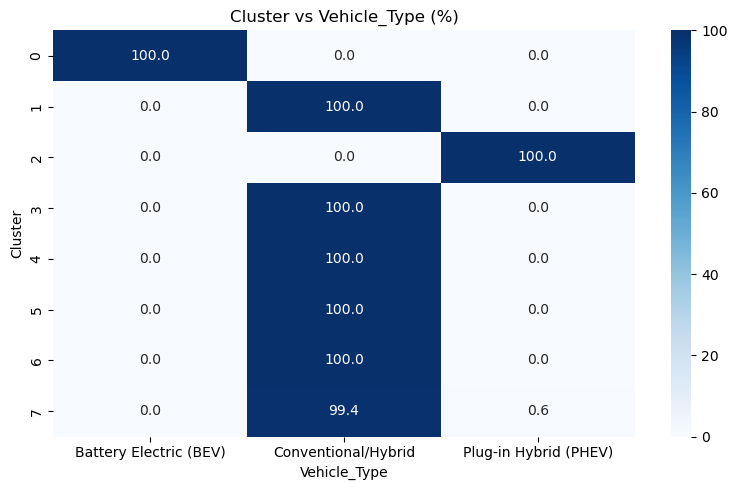


Cluster vs Fuel_Type_Primary (% within cluster):


Fuel_Type_Primary,B,B/X,B/X*,B/Z,B/Z*,D,E,N,X,Z
cluster,,,,,,,,,,
0,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.363196,11.501211,0.00000,49.636804,38.498789
2,9.974425,2.813299,29.923274,8.951407,48.337596,0.000000,0.000000,0.00000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,2.555448,0.916104,0.00000,57.666345,38.862102
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.781145,0.06734,22.558923,72.592593
5,0.000000,0.000000,0.000000,0.000000,0.000000,8.388158,16.940789,0.00000,70.559211,4.111842
6,0.000000,0.000000,0.000000,0.000000,0.000000,5.050505,1.262626,0.00000,74.116162,19.570707
7,0.000000,0.000000,0.000000,0.601202,0.000000,0.000000,6.412826,0.00000,16.232465,76.753507


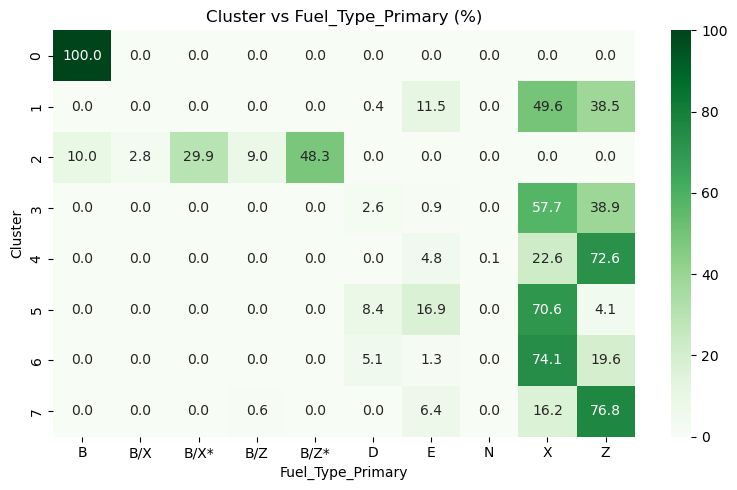


Saved:
 - cluster_vs_vehicle_type_pct_v1.csv (if Vehicle_Type exists)
 - cluster_vs_fuel_type_pct_v1.csv (if Fuel_Type_Primary exists)


In [18]:
# ============================================================
# Step 13: Cluster vs ground-truth comparison
# Goal:
# compare unsupervised clusters with original vehicle categories
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

print("=== Step 13: Cluster vs Ground-Truth Comparison ===")

# ------------------------------------------------------------
# 1. Load original data and attach cluster labels
# ------------------------------------------------------------
file_path = "vehicles_clustering_features (1).csv"
df_gt = pd.read_csv(file_path)

if len(df_gt) != len(best_labels):
    raise ValueError(
        f"Row count mismatch: original CSV has {len(df_gt)} rows, "
        f"but best_labels has {len(best_labels)} rows."
    )

df_gt["cluster"] = best_labels

# ------------------------------------------------------------
# 2. Cluster vs Vehicle_Type
# ------------------------------------------------------------
if "Vehicle_Type" in df_gt.columns:
    ct_vehicle_type = pd.crosstab(
        df_gt["cluster"],
        df_gt["Vehicle_Type"],
        normalize="index"
    ) * 100

    print("\nCluster vs Vehicle_Type (% within cluster):")
    display(ct_vehicle_type)

    plt.figure(figsize=(8, 5))
    sns.heatmap(ct_vehicle_type, annot=True, fmt=".1f", cmap="Blues")
    plt.title("Cluster vs Vehicle_Type (%)")
    plt.xlabel("Vehicle_Type")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    ct_vehicle_type.to_csv("cluster_vs_vehicle_type_pct_v1.csv")

# ------------------------------------------------------------
# 3. Cluster vs Fuel_Type_Primary
# ------------------------------------------------------------
if "Fuel_Type_Primary" in df_gt.columns:
    ct_fuel_type = pd.crosstab(
        df_gt["cluster"],
        df_gt["Fuel_Type_Primary"],
        normalize="index"
    ) * 100

    print("\nCluster vs Fuel_Type_Primary (% within cluster):")
    display(ct_fuel_type)

    plt.figure(figsize=(8, 5))
    sns.heatmap(ct_fuel_type, annot=True, fmt=".1f", cmap="Greens")
    plt.title("Cluster vs Fuel_Type_Primary (%)")
    plt.xlabel("Fuel_Type_Primary")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

    ct_fuel_type.to_csv("cluster_vs_fuel_type_pct_v1.csv")

print("\nSaved:")
print(" - cluster_vs_vehicle_type_pct_v1.csv (if Vehicle_Type exists)")
print(" - cluster_vs_fuel_type_pct_v1.csv (if Fuel_Type_Primary exists)")

---
## Appendix · Supplementary Robustness Check at K = 4

The sections below repeat model comparison and basic visualisation using **K = 4** (suggested by the elbow curve). This is included solely as a supplementary validation to confirm that the elbow-based alternative does not outperform the multi-metric recommendation of K = 8. **The primary analysis and all interpretation above use K = 8.**

### A.1 Model Comparison at K = 4

In [19]:
# ============================================================
# Step 8B (ELBOW VERSION): Compare clustering models using fixed K=4
# Input:
# - X_pca_df from Step 7
# Goal:
# 1) force K=4 based on elbow interpretation
# 2) compare KMeans / Hierarchical / GaussianMixture fairly
# 3) select the best model under K=4
# ============================================================

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from IPython.display import display

print("=== Step 8B (Elbow-fixed): Compare Clustering Models at K=4 ===")

# ------------------------------------------------------------
# 1. Input data
# ------------------------------------------------------------
X_model_input = X_pca_df.copy()
best_k = 4   # force K=4 based on elbow result

print(f"Input shape for model comparison: {X_model_input.shape}")
print(f"Forced best_k = {best_k}")

model_results = []
cluster_size_tables = []

# ------------------------------------------------------------
# 2. KMeans
# ------------------------------------------------------------
km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
km_labels = km.fit_predict(X_model_input)

model_results.append({
    "Model": "KMeans",
    "Silhouette": silhouette_score(X_model_input, km_labels),
    "Davies_Bouldin": davies_bouldin_score(X_model_input, km_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_model_input, km_labels),
    "Labels": km_labels
})

# ------------------------------------------------------------
# 3. Hierarchical (Ward linkage)
# ------------------------------------------------------------
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_model_input)

model_results.append({
    "Model": "Hierarchical",
    "Silhouette": silhouette_score(X_model_input, agg_labels),
    "Davies_Bouldin": davies_bouldin_score(X_model_input, agg_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_model_input, agg_labels),
    "Labels": agg_labels
})

# ------------------------------------------------------------
# 4. Gaussian Mixture
# ------------------------------------------------------------
gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X_model_input)

model_results.append({
    "Model": "GaussianMixture",
    "Silhouette": silhouette_score(X_model_input, gmm_labels),
    "Davies_Bouldin": davies_bouldin_score(X_model_input, gmm_labels),
    "Calinski_Harabasz": calinski_harabasz_score(X_model_input, gmm_labels),
    "Labels": gmm_labels
})

# ------------------------------------------------------------
# 5. Build evaluation table
# ------------------------------------------------------------
model_eval = pd.DataFrame([
    {k: v for k, v in r.items() if k != "Labels"}
    for r in model_results
])

# Rank-based summary
model_eval["Rank_Silhouette"] = model_eval["Silhouette"].rank(ascending=False, method="min")
model_eval["Rank_Davies_Bouldin"] = model_eval["Davies_Bouldin"].rank(ascending=True, method="min")
model_eval["Rank_Calinski_Harabasz"] = model_eval["Calinski_Harabasz"].rank(ascending=False, method="min")

model_eval["Rank_Sum"] = (
    model_eval["Rank_Silhouette"] +
    model_eval["Rank_Davies_Bouldin"] +
    model_eval["Rank_Calinski_Harabasz"]
)

# ------------------------------------------------------------
# 6. Cluster size distribution for each model
# ------------------------------------------------------------
for result in model_results:
    labels = result["Labels"]
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    size_df = pd.DataFrame({
        "Model": result["Model"],
        "Cluster": cluster_sizes.index,
        "Size": cluster_sizes.values
    })
    cluster_size_tables.append(size_df)

    model_eval.loc[model_eval["Model"] == result["Model"], "Min_Cluster_Size"] = int(cluster_sizes.min())
    model_eval.loc[model_eval["Model"] == result["Model"], "Max_Cluster_Size"] = int(cluster_sizes.max())

cluster_sizes_all_models = pd.concat(cluster_size_tables, ignore_index=True)

# Sort final table
model_eval = model_eval.sort_values(
    ["Rank_Sum", "Silhouette"],
    ascending=[True, False]
).reset_index(drop=True)

print("\nModel evaluation summary at K=4:")
display(model_eval)

print("\nCluster sizes by model at K=4:")
display(cluster_sizes_all_models)

# ------------------------------------------------------------
# 7. Select best model
# ------------------------------------------------------------
best_model_idx = model_eval["Rank_Sum"].idxmin()
best_model_name = model_eval.loc[best_model_idx, "Model"]

best_labels = None
for r in model_results:
    if r["Model"] == best_model_name:
        best_labels = r["Labels"]
        break

print(f"\nBest model at K=4 based on combined ranking: {best_model_name}")

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
model_eval.to_csv("clustering_model_comparison_k4.csv", index=False)
cluster_sizes_all_models.to_csv("clustering_model_cluster_sizes_k4.csv", index=False)

print("\nSaved:")
print(" - clustering_model_comparison_k4.csv")
print(" - clustering_model_cluster_sizes_k4.csv")

=== Step 8B (Elbow-fixed): Compare Clustering Models at K=4 ===
Input shape for model comparison: (7870, 4)
Forced best_k = 4

Model evaluation summary at K=4:


,Model,Silhouette,Davies_Bouldin,Calinski_Harabasz,Rank_Silhouette,Rank_Davies_Bouldin,Rank_Calinski_Harabasz,Rank_Sum,Min_Cluster_Size,Max_Cluster_Size
0,GaussianMixture,0.543930,0.528513,14433.541025,1.0,1.0,3.0,5.0,394.0,5673.0
1,KMeans,0.496686,0.732251,16811.248976,2.0,3.0,1.0,6.0,390.0,4395.0
2,Hierarchical,0.424556,0.667697,15160.299055,3.0,2.0,2.0,7.0,391.0,4210.0



Cluster sizes by model at K=4:


,Model,Cluster,Size
0,KMeans,0,4395
1,KMeans,1,1195
2,KMeans,2,1890
3,KMeans,3,390
4,Hierarchical,0,4210
5,Hierarchical,1,1195
6,Hierarchical,2,391
7,Hierarchical,3,2074
8,GaussianMixture,0,608
9,GaussianMixture,1,1195



Best model at K=4 based on combined ranking: GaussianMixture

Saved:
 - clustering_model_comparison_k4.csv
 - clustering_model_cluster_sizes_k4.csv


### A.2 PCA Cluster Plot (K = 4)

=== Step 9A: PCA Cluster Plot (K=4) ===
Plot dataframe shape: (7870, 5)
Number of clusters in best_labels: 4


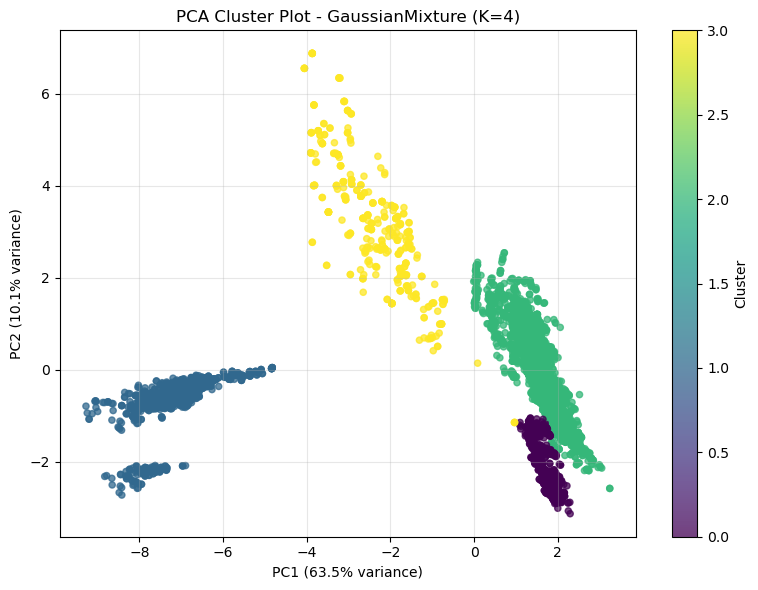


Saved:
 - pca_cluster_plot_data_k4.csv


In [20]:
# ============================================================
# Step 9A: PCA cluster plot for K=4 selected final model
# Input:
# - X_pca_df
# - best_labels
# - best_model_name
# - best_k
# - pca_final
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=== Step 9A: PCA Cluster Plot (K=4) ===")

plot_df = X_pca_df.copy()
plot_df["cluster"] = best_labels

print(f"Plot dataframe shape: {plot_df.shape}")
print(f"Number of clusters in best_labels: {plot_df['cluster'].nunique()}")

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["cluster"],
    s=20,
    alpha=0.75
)

pc1_var = pca_final.explained_variance_ratio_[0] * 100
pc2_var = pca_final.explained_variance_ratio_[1] * 100 if pca_final.n_components_ >= 2 else 0

plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)")
plt.title(f"PCA Cluster Plot - {best_model_name} (K={best_k})")
plt.colorbar(scatter, label="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_df.to_csv("pca_cluster_plot_data_k4.csv", index=False)

print("\nSaved:")
print(" - pca_cluster_plot_data_k4.csv")

### A.3 Attach Cluster Labels (K = 4)

In [21]:
# ============================================================
# Step 9B: Attach final cluster labels back to selected features
# Input:
# - df_selected_v1
# - best_labels
# ============================================================

import pandas as pd
from IPython.display import display

print("=== Step 9B: Attach Cluster Labels to Original Features (K=4) ===")

df_clustered_v1 = df_selected_v1.copy()
df_clustered_v1["cluster"] = best_labels

print(f"df_clustered_v1 shape: {df_clustered_v1.shape}")
print("\nCluster counts:")
display(df_clustered_v1["cluster"].value_counts().sort_index().to_frame(name="Count"))

df_clustered_v1.to_csv("vehicles_with_clusters_selected_features_k4.csv", index=False)

print("\nSaved:")
print(" - vehicles_with_clusters_selected_features_k4.csv")

=== Step 9B: Attach Cluster Labels to Original Features (K=4) ===
df_clustered_v1 shape: (7870, 17)

Cluster counts:


,Count
cluster,
0,608
1,1195
2,5673
3,394



Saved:
 - vehicles_with_clusters_selected_features_k4.csv
